# Домашна работа број 1

Во рамки на оваа домашна задача, целта е да се развие модел за предвидување на напуштање на клиент (customer churn prediction) врз основа на историски податоци од постојни индустриски компании-клиенти. На располагање се податоци составени од 18 различни карактеристики (features), кои ја опишуваат активноста, историјата, употребата на услугите и други релевантни параметри за секој клиент. Дополнително, за секој клиент е означено дали го раскинал договорот или останат активен, што овозможува проблемот да се формулира како задача за бинарна класификација.

Целта на моделот е:

- да ја научи поврзаноста помеѓу дадените карактеристики и однесувањето на клиентите,

- да ги препознае факторите кои најмногу влијаат на одлуката за раскинување договор,

- и да може со висока точност да предвиди дали нов или постоечки клиент би ја напуштил компанијата.



Точната идентификација на ризични клиенти им овозможува на компаниите превентивно да реагираат – преку подобрување на услугите, комуникација со клиентот, персонализирани понуди и оптимално планирање на ресурси. На тој начин, предвидувањето на напуштање претставува клучен дел од современите системи за поддршка при донесување одлуки.

### Локална инсталација на потребните библиотеки

In [1]:
!pip install numpy pandas seaborn matplotlib scikit-learn xgboost catboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\DD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Подготовка на податоци - Data Preprocessing

### Вклучување на потребните библиотеки

In [2]:
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-white")

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [4]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Вчитување на податочното множество со помош на pandas, формирајќи pandas податочна рамка

In [7]:
data = pd.read_csv('IndustrialMaintenanceClientRetention_Training.csv')

In [8]:
data.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,facility_role_type,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,months_with_provider,num_prior_providers,onsite_service_satisfaction,overall_contract_satisfaction,preventive_training_sessions_last_year,service_package_tier,staff_skill_level,total_equipment_age,years_operating_facility
0,1,0,3,3,No,1,3,PrecisionManufacturing,2,2177,0,1.0,3.0,3,4.0,6,Silver,3.0,18,45
1,2,0,3,3,No,2,4,PharmaceuticalProduction,4,6842,4,5.0,6.0,4,1.0,3,Silver,2.0,24,22
2,3,0,8,3,No,2,3,HeavyIndustrialProcessing,3,5121,0,0.0,3.0,2,1.0,3,Silver,5.0,18,20
3,4,0,8,3,No,3,3,AdvancedAutomationCenter,2,13757,8,9.0,2.0,4,2.0,5,Silver,1.0,27,26
4,5,1,9,3,No,1,3,PackagingAndFinishing,2,4400,2,3.0,3.0,1,1.0,2,Bronze,2.0,17,11


### Статистички опис на податоците

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      1087 non-null   int64  
 1   contract_terminated                     1087 non-null   int64  
 2   distance_to_service_hub                 1087 non-null   int64  
 3   downtime_tolerance                      1087 non-null   int64  
 4   emergency_service_usage                 1086 non-null   object 
 5   equipment_complexity_level              1087 non-null   int64  
 6   equipment_health_score                  1087 non-null   int64  
 7   facility_role_type                      1087 non-null   object 
 8   maintenance_engagement_level            1087 non-null   int64  
 9   monthly_service_fee                     1087 non-null   int64  
 10  months_on_current_service_tier          1087 non-null   int6

Ова податочно множество опфаќа 1087 записи и 20 колони, каде секој ред претставува еден клиент. Колоните носат информации за различни аспекти – од техничката состојба и комплексност на опремата, преку историјата на користење услуги, па сè до нивото на задоволство на клиентите.


Податоците комбинираат нумерички вредности  и категориски атрибути. Од интерес е колоната contract_terminated, која покажува дали клиентот го прекинал договорот и служи како целна променлива за моделирање.

Останатите карактеристики откриваат фактори што можат да влијаат врз однесувањето на клиентите: растојанието до сервисниот центар, месечната цена на услугата, здравјето и староста на опремата, нивото на ангажман околу одржување, како и оценките за задоволство и квалитетот на персоналот.

In [10]:
object_column_names = data.select_dtypes(include='object').columns.tolist()
[print(f"{col}: {data[col].unique()}") for col in object_column_names]

emergency_service_usage: ['No' 'Yes' nan]
facility_role_type: ['PrecisionManufacturing' 'PharmaceuticalProduction'
 'HeavyIndustrialProcessing' 'AdvancedAutomationCenter'
 'PackagingAndFinishing' 'LogisticsAndDistribution'
 'TestingAndCalibration' 'AssemblyFacility' 'Other']
service_package_tier: ['Silver' 'Bronze' 'Gold' 'Enterprise' nan]


[None, None, None]

In [11]:
low_unique = []
high_unique = []

for col in data.columns:
    n_unique = data[col].nunique()
    if n_unique <= 5:
        low_unique.append((col, n_unique))
    else:
        high_unique.append((col, n_unique))


In [12]:
print(" Колони со <= 5 уникатни вредности:")
for col, n in low_unique:
    print(f"{col}: {n} уникатни вредности")

 Колони со <= 5 уникатни вредности:
contract_terminated: 2 уникатни вредности
downtime_tolerance: 4 уникатни вредности
emergency_service_usage: 2 уникатни вредности
equipment_complexity_level: 5 уникатни вредности
equipment_health_score: 2 уникатни вредности
maintenance_engagement_level: 4 уникатни вредности
onsite_service_satisfaction: 4 уникатни вредности
overall_contract_satisfaction: 4 уникатни вредности
service_package_tier: 4 уникатни вредности
staff_skill_level: 5 уникатни вредности


In [13]:
print("\n Колони со > 5 уникатни вредности:")
for col, n in high_unique:
    print(f"{col}: {n} уникатни вредности")


 Колони со > 5 уникатни вредности:
ID: 1087 уникатни вредности
distance_to_service_hub: 29 уникатни вредности
facility_role_type: 9 уникатни вредности
monthly_service_fee: 1017 уникатни вредности
months_on_current_service_tier: 19 уникатни вредности
months_with_provider: 37 уникатни вредности
num_prior_providers: 11 уникатни вредности
preventive_training_sessions_last_year: 7 уникатни вредности
total_equipment_age: 40 уникатни вредности
years_operating_facility: 43 уникатни вредности


In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1087.0,544.000000,313.934176,1.0,272.5,544.0,815.5,1087.0
contract_terminated,1087.0,0.160074,0.366843,0.0,0.0,0.0,0.0,1.0
distance_to_service_hub,1087.0,9.210672,8.102517,1.0,2.0,7.0,14.0,29.0
downtime_tolerance,1087.0,2.760810,0.701098,1.0,2.0,3.0,3.0,4.0
equipment_complexity_level,1087.0,2.075437,1.118163,1.0,1.0,2.0,3.0,5.0
equipment_health_score,1087.0,3.161914,0.368541,3.0,3.0,3.0,3.0,4.0
maintenance_engagement_level,1087.0,2.727691,0.707365,1.0,2.0,3.0,3.0,4.0
monthly_service_fee,1087.0,6585.310948,4784.502630,-299.0,2911.0,4999.0,8630.5,19943.0
months_on_current_service_tier,1087.0,4.191352,3.625188,0.0,2.0,3.0,7.0,18.0
months_with_provider,1085.0,7.026728,6.203069,0.0,3.0,5.0,10.0,40.0


Во податочното множество се појавуваат две очигледни аномалии што веднаш привлекуваат внимание.


Првата е кај колоната num_prior_providers, каде што максималната вредност е внесена како 9,999,999. Таков број е нереален и не може да се објасни во реален контекст. Дополнително, просекот е околу 9227, но со огромна варијабилност, што укажува дека овие екстремни вредности ја нарушуваат целата статистика. Најверојатно станува збор за грешка при внесување.


Втората аномалија е кај колоната monthly_service_fee, каде што минималната вредност е -299. Негативна месечна цена е нелогична, бидејќи услугите не можат да имаат негативен износ. Ова најверојатно е резултат на погрешно внесен знак или пак специјален код што означува попуст или кредит.



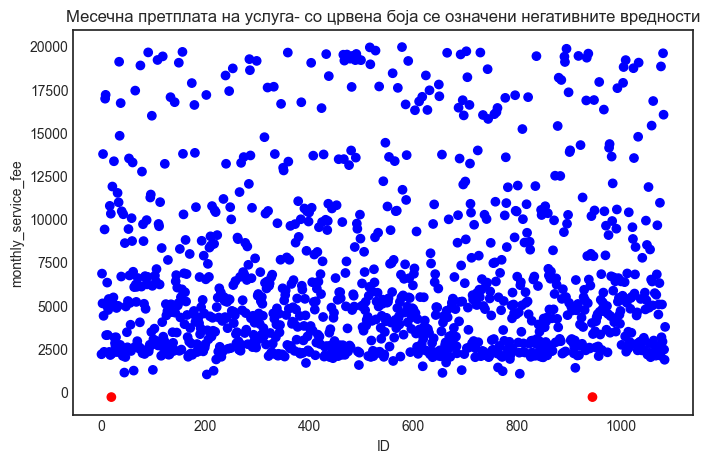

In [15]:
colors = ['red' if x < 0 else 'blue' for x in data['monthly_service_fee']]

plt.figure(figsize=(8,5))
plt.scatter(data.index, data['monthly_service_fee'], c=colors)
plt.xlabel("ID")
plt.ylabel("monthly_service_fee")
plt.title("Месечна претплата на услуга- со црвена боја се означени негативните вредности")
plt.show()

In [16]:
Q1 = data['num_prior_providers'].quantile(0.25)
Q3 = data['num_prior_providers'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR

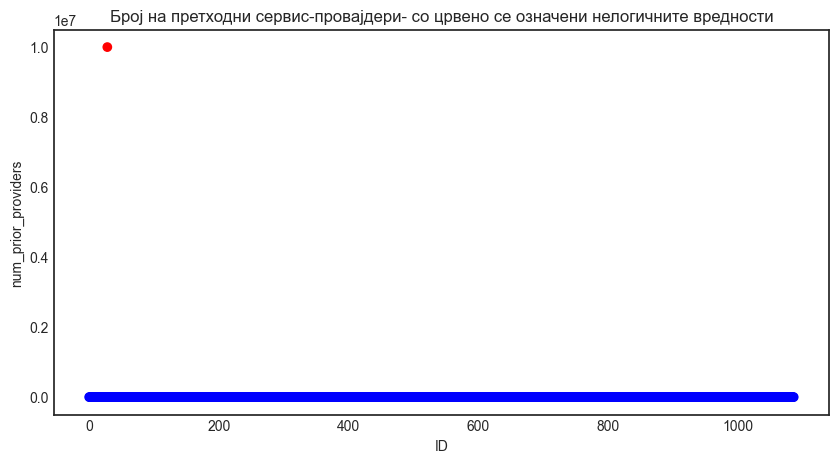

In [17]:
threshold = 100  
colors = ['red' if y > threshold else 'blue' for y in data['num_prior_providers']]

plt.figure(figsize=(10,5))
plt.scatter(data.index, data['num_prior_providers'], c=colors)
plt.xlabel("ID")
plt.ylabel("num_prior_providers")
plt.title("Број на претходни сервис-провајдери- со црвено се означени нелогичните вредности")
plt.show()

In [18]:
data_resenie1=data.copy()

Во првиот обид за анализа не беа отстранети екстремните вредности и тоа веднаш се покажа како проблем. На пример, кај колоната „num_prior_providers“ се појавува нереален максимум од 9,999,999, што очигледно не може да биде вистински број на претходни провајдери. Слично, кај „monthly_service_fee“ има вредност од -299, што е нелогично бидејќи месечна цена не може да биде негативна.


Ако ваквите outliers се остават во податочното множество, тие ја искривуваат статистиката – просекот и стандардната девијација стануваат неточни, а моделите за машинско учење можат да донесат погрешни предвидувања. Наместо да ја одразуваат реалната состојба, резултатите ќе бидат пристрасни и нестабилни. Затоа е важно овие екстремни вредности да се идентификуваат и да се третираат навреме, за да се обезбеди точна анализа и сигурно моделирање.

In [19]:
data.loc[data['monthly_service_fee'] < 0, 'monthly_service_fee'] = np.nan

Повторно ја пресметуваме медијаната на оваа колона за да илустрираме колкаво влијание имала оваа екстремно нелогична, негативна вредност.

In [20]:
median_fee = data['monthly_service_fee'].median()

In [21]:
print(f" Пресметана медијана со изоставена екстремна вредност : {median_fee:,.2f}")

 Пресметана медијана со изоставена екстремна вредност : 5,003.00


In [22]:
data.loc[data['num_prior_providers'] > 9999998.0, 'num_prior_providers'] = np.nan

In [23]:
median_prior_providers = data['num_prior_providers'].median()

In [24]:
print(f" Пресметана медијана со изоставена екстремна вредност : {median_prior_providers:,.2f}")

 Пресметана медијана со изоставена екстремна вредност : 2.00


##### Справување со NaN вредности

##### За најдобро решение

In [25]:
missing_by_column = data.isnull().sum()
print("Број на NaN вредности по колона:\n", missing_by_column)

Број на NaN вредности по колона:
 ID                                        0
contract_terminated                       0
distance_to_service_hub                   0
downtime_tolerance                        0
emergency_service_usage                   1
equipment_complexity_level                0
equipment_health_score                    0
facility_role_type                        0
maintenance_engagement_level              0
monthly_service_fee                       2
months_on_current_service_tier            0
months_with_provider                      2
num_prior_providers                       4
onsite_service_satisfaction               0
overall_contract_satisfaction             1
preventive_training_sessions_last_year    0
service_package_tier                      1
staff_skill_level                         1
total_equipment_age                       0
years_operating_facility                  0
dtype: int64


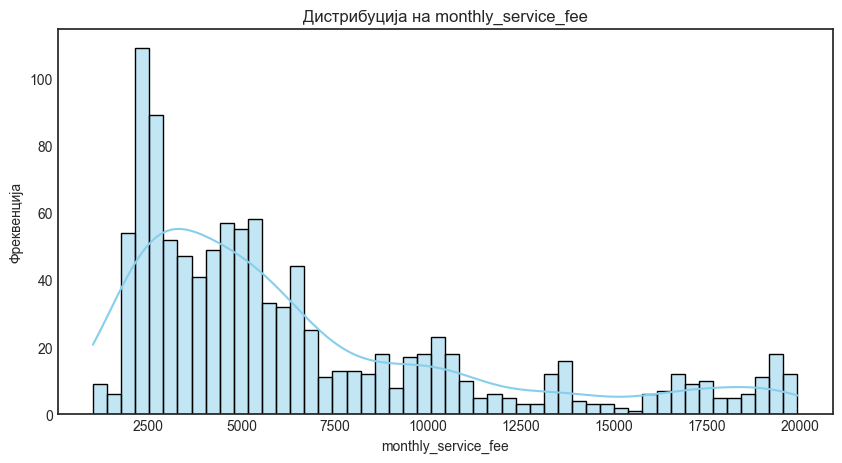

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(data['monthly_service_fee'], bins=50, kde=True, color='skyblue')
plt.xlabel("monthly_service_fee")
plt.ylabel("Фреквенција")
plt.title("Дистрибуција на monthly_service_fee")
plt.show()

Избираме за овој податок NaN вредностите да се пополнат со медијана. 

Извор: https://www.kaggle.com/code/mrisdal/exploring-survival-on-the-titanic

Распределбата на колоната monthly_service_fee е јасно десно асиметрична – има многу записи со ниски вредности и само неколку со исклучително високи износи. Оваа форма на распределба е важна да се земе предвид кога се пополнуваат NaN вредностите.

Ако се користи средната вредност (mean), екстремно високите износи (над 15.000 или 20.000) ќе ја повлечат средната нагоре. Тоа значи дека празните места ќе се пополнат со неприродно високи вредности, што ќе внесе пристрасност и ќе ја искриви реалната слика за податоците.

Од друга страна, медијаната е многу поотпорна на outlier-и. Таа ја претставува средишната точка на распределбата и кај асиметрични податоци подобро ја одразува типичната вредност. Со пополнување на празнините со медијана, се задржува природниот опсег на податоците и се избегнува создавање неправилни шаблони што би можеле да влијаат негативно врз моделите за машинско учење.


In [27]:
data['monthly_service_fee'] = data['monthly_service_fee'].fillna(median_fee)

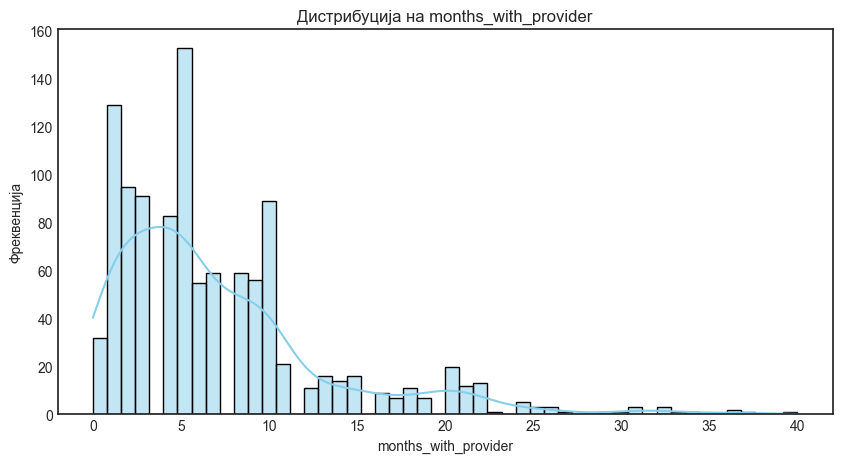

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(data['months_with_provider'], bins=50, kde=True, color='skyblue')
plt.xlabel("months_with_provider")
plt.ylabel("Фреквенција")
plt.title("Дистрибуција на months_with_provider")
plt.show()

Резонирањето е слично како и за претходната колона.

In [29]:
median_value = data['months_with_provider'].median()  
data['months_with_provider'] = data['months_with_provider'].fillna(median_value) 

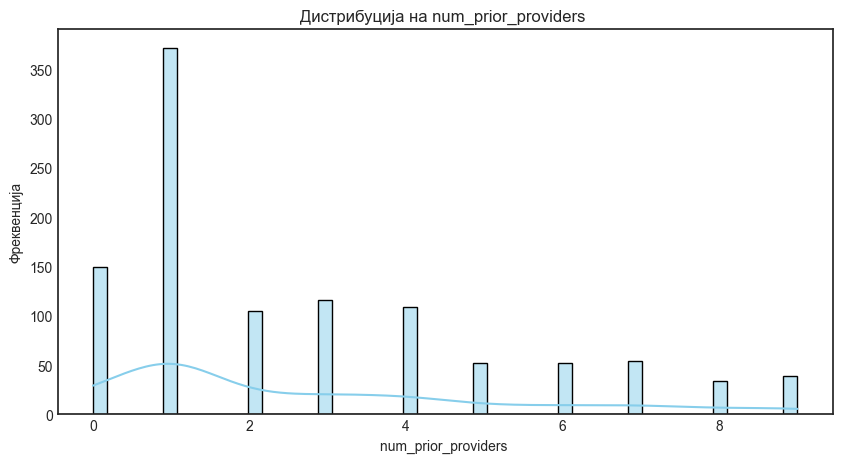

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(data['num_prior_providers'], bins=50, kde=True, color='skyblue')
plt.xlabel("num_prior_providers ")
plt.ylabel("Фреквенција")
plt.title("Дистрибуција на num_prior_providers ")
plt.show()

In [31]:

median_value = data['num_prior_providers'].median()  
data['num_prior_providers'] = data['num_prior_providers'].fillna(median_value) 

In [32]:
print(data['overall_contract_satisfaction'].unique())
print(data['overall_contract_satisfaction'].value_counts())


[ 4.  1.  2.  3. nan]
overall_contract_satisfaction
4.0    349
3.0    321
1.0    216
2.0    200
Name: count, dtype: int64


In [33]:
print('Најзастапена вредност е : ', data['overall_contract_satisfaction'].mode())
fill_NaN=0;

Најзастапена вредност е :  0    4.0
Name: overall_contract_satisfaction, dtype: float64


In [34]:
data['overall_contract_satisfaction'].fillna(fill_NaN,inplace = True)

C:\Users\DD\AppData\Local\Temp\ipykernel_21364\217047055.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['overall_contract_satisfaction'].fillna(fill_NaN,inplace = True)


In [35]:
print('Најзастапена вредност е : ', data['service_package_tier'].mode())

Најзастапена вредност е :  0    Bronze
Name: service_package_tier, dtype: object


In [36]:
fill_Nan='Bronze';

In [37]:
data['service_package_tier'].fillna(fill_NaN,inplace = True)

C:\Users\DD\AppData\Local\Temp\ipykernel_21364\3712308641.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['service_package_tier'].fillna(fill_NaN,inplace = True)


In [38]:

print('Најзастапена вредност е : ', data['staff_skill_level'].mode())

Најзастапена вредност е :  0    3.0
Name: staff_skill_level, dtype: float64


In [39]:
fill_Nan=3;

In [40]:
data['staff_skill_level'].fillna(fill_NaN,inplace = True)

C:\Users\DD\AppData\Local\Temp\ipykernel_21364\3547181991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['staff_skill_level'].fillna(fill_NaN,inplace = True)


In [41]:
print('Најзастапена вредност е : ', data['emergency_service_usage'].mode())

Најзастапена вредност е :  0    No
Name: emergency_service_usage, dtype: object


In [42]:
fill_Nan='No';

In [43]:
data['emergency_service_usage'].fillna(fill_NaN,inplace = True)

C:\Users\DD\AppData\Local\Temp\ipykernel_21364\3127201627.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['emergency_service_usage'].fillna(fill_NaN,inplace = True)


In [44]:
missing_by_column = data.isnull().sum()
print("Број на NaN вредности по колона:\n", missing_by_column)

Број на NaN вредности по колона:
 ID                                        0
contract_terminated                       0
distance_to_service_hub                   0
downtime_tolerance                        0
emergency_service_usage                   0
equipment_complexity_level                0
equipment_health_score                    0
facility_role_type                        0
maintenance_engagement_level              0
monthly_service_fee                       0
months_on_current_service_tier            0
months_with_provider                      0
num_prior_providers                       0
onsite_service_satisfaction               0
overall_contract_satisfaction             0
preventive_training_sessions_last_year    0
service_package_tier                      0
staff_skill_level                         0
total_equipment_age                       0
years_operating_facility                  0
dtype: int64


##### За второ по ред најдобро решение

Во овој дел не постои разлика. Сите 3 различни решенија, ги имаат пополнето своите NaN вредности на идентичен начин.

In [45]:
print("Број на NaN вредности по колона:")
print(data_resenie1.isnull().sum())

Број на NaN вредности по колона:
ID                                        0
contract_terminated                       0
distance_to_service_hub                   0
downtime_tolerance                        0
emergency_service_usage                   1
equipment_complexity_level                0
equipment_health_score                    0
facility_role_type                        0
maintenance_engagement_level              0
monthly_service_fee                       0
months_on_current_service_tier            0
months_with_provider                      2
num_prior_providers                       3
onsite_service_satisfaction               0
overall_contract_satisfaction             1
preventive_training_sessions_last_year    0
service_package_tier                      1
staff_skill_level                         1
total_equipment_age                       0
years_operating_facility                  0
dtype: int64


In [46]:
data_resenie1=data.copy()

In [47]:
data_resenie1.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,facility_role_type,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,months_with_provider,num_prior_providers,onsite_service_satisfaction,overall_contract_satisfaction,preventive_training_sessions_last_year,service_package_tier,staff_skill_level,total_equipment_age,years_operating_facility
0,1,0,3,3,No,1,3,PrecisionManufacturing,2,2177.0,0,1.0,3.0,3,4.0,6,Silver,3.0,18,45
1,2,0,3,3,No,2,4,PharmaceuticalProduction,4,6842.0,4,5.0,6.0,4,1.0,3,Silver,2.0,24,22
2,3,0,8,3,No,2,3,HeavyIndustrialProcessing,3,5121.0,0,0.0,3.0,2,1.0,3,Silver,5.0,18,20
3,4,0,8,3,No,3,3,AdvancedAutomationCenter,2,13757.0,8,9.0,2.0,4,2.0,5,Silver,1.0,27,26
4,5,1,9,3,No,1,3,PackagingAndFinishing,2,4400.0,2,3.0,3.0,1,1.0,2,Bronze,2.0,17,11


##### Енкодирање

In [48]:
!pip install ipython pillow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\DD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


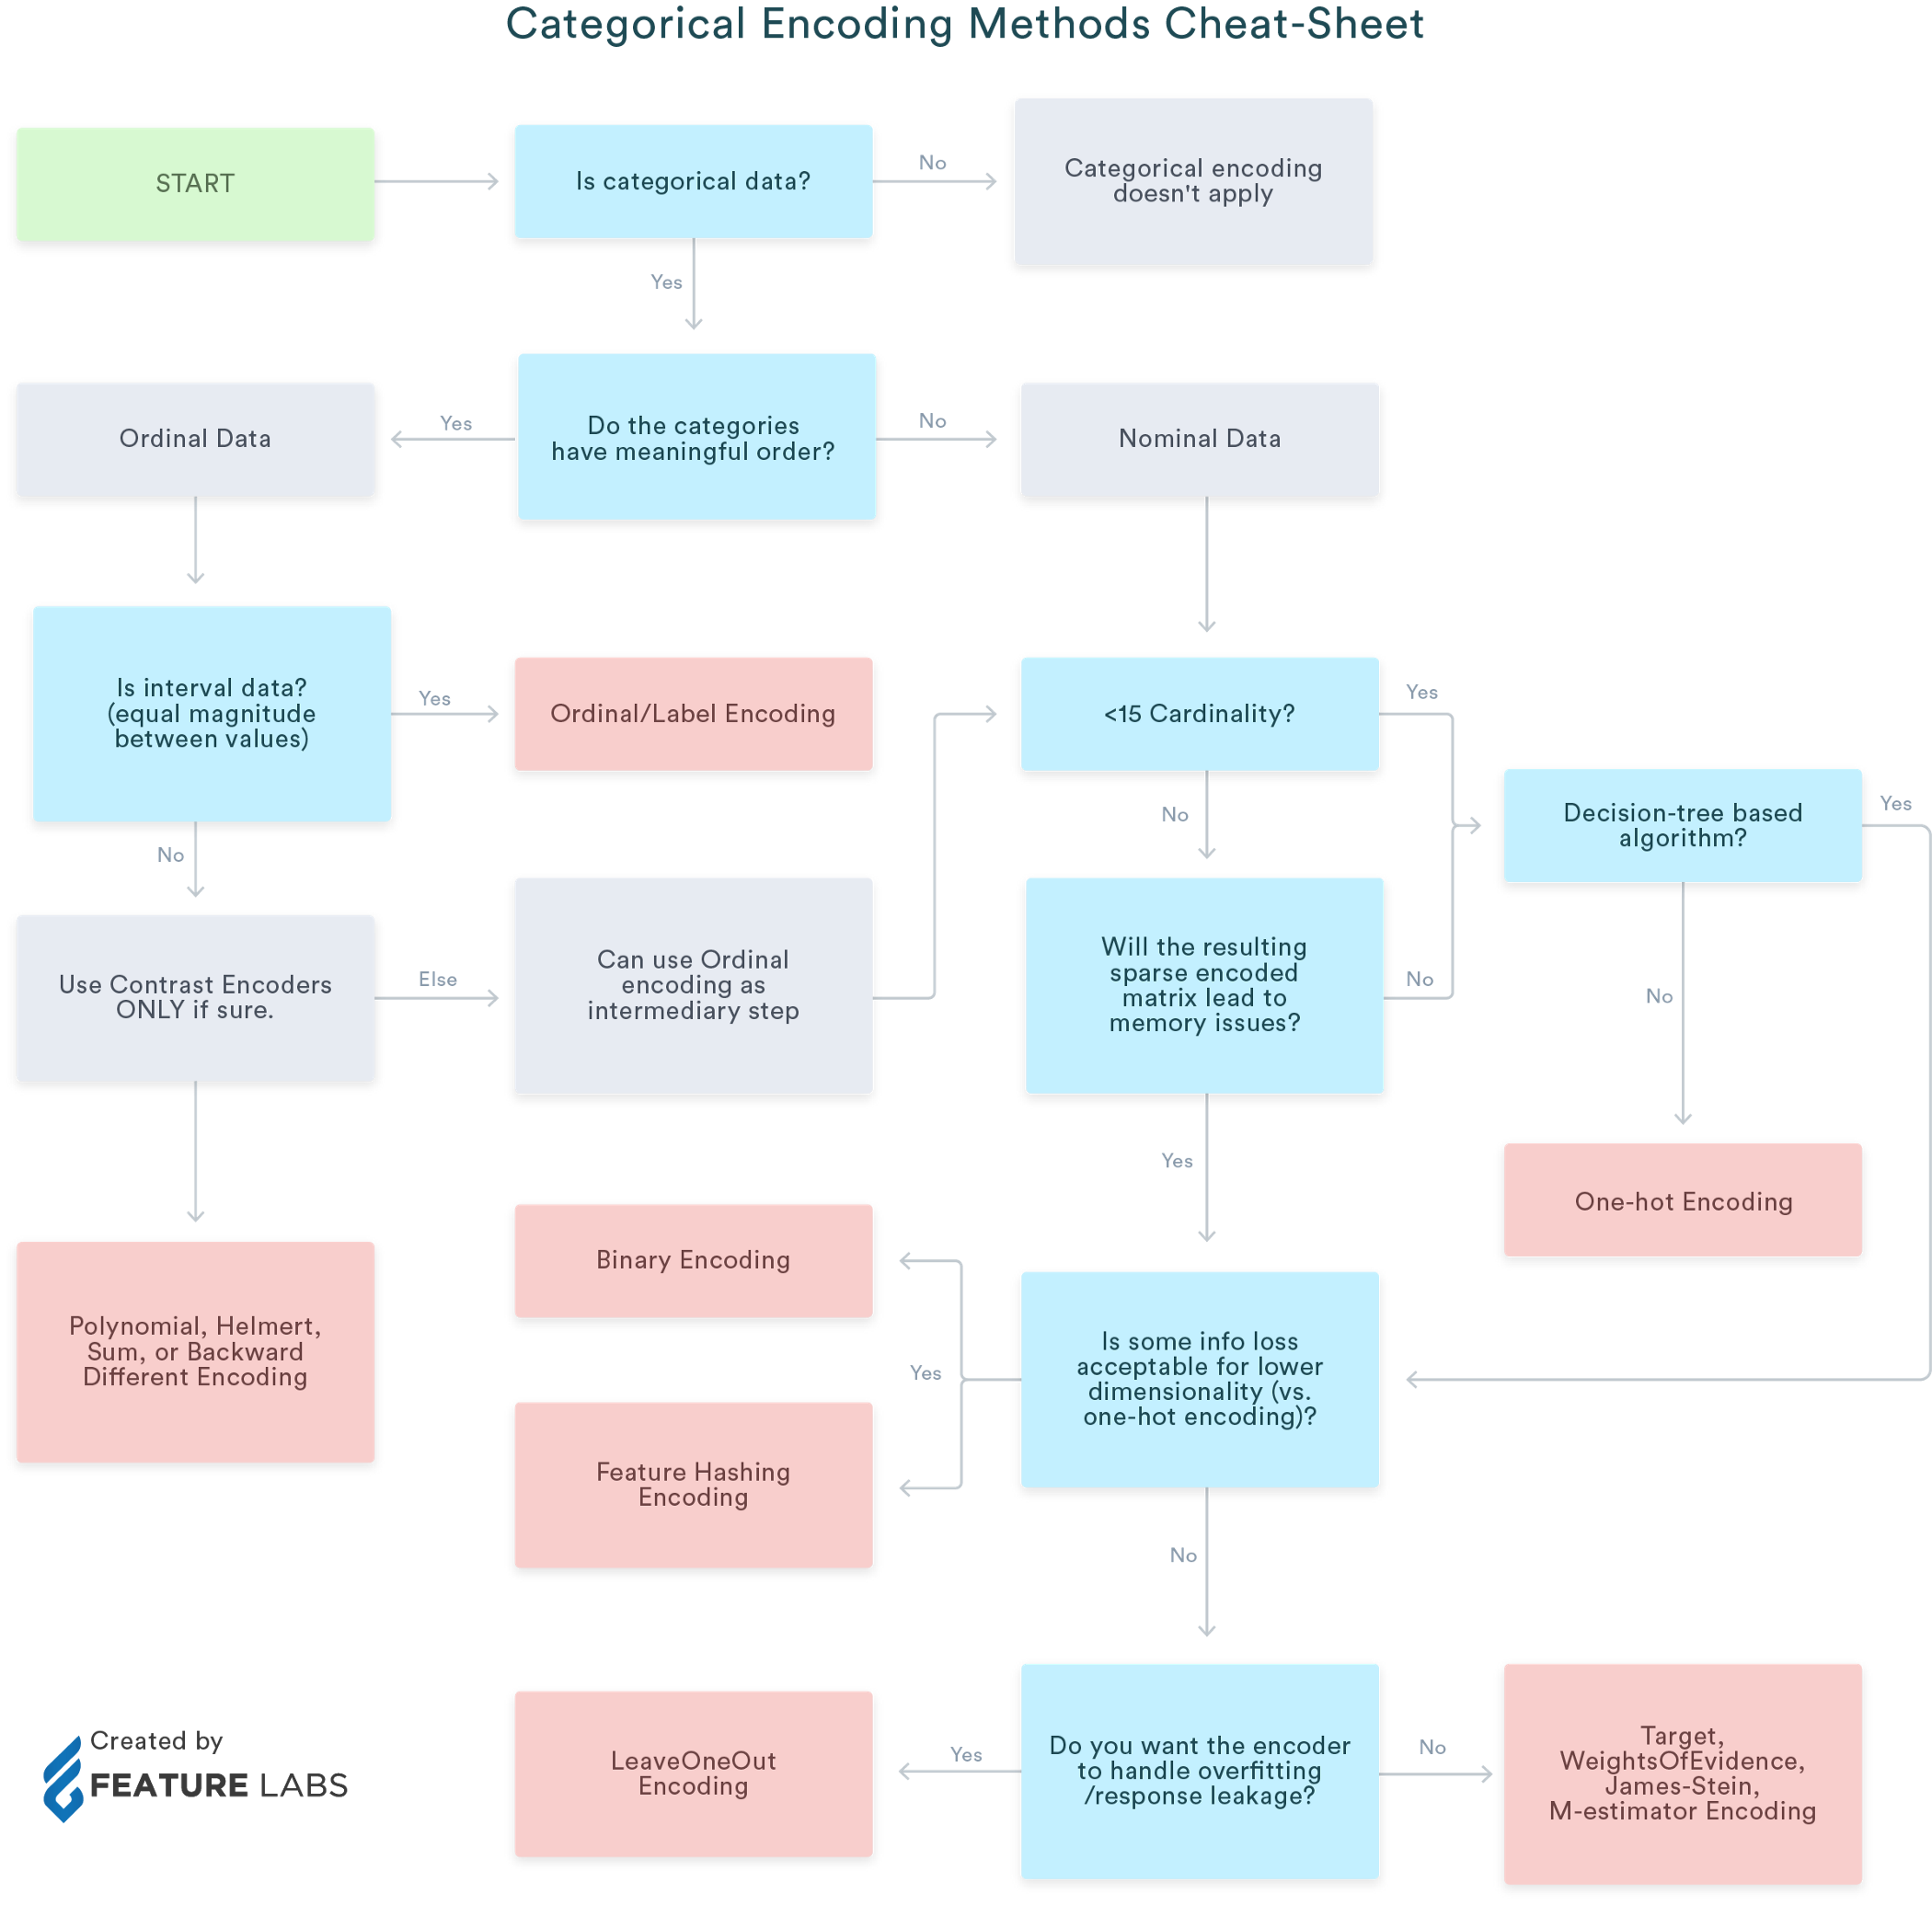

In [49]:
from IPython.display import Image, display
display(Image(filename='encoding.png'))


https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction; 


https://datascience.stackexchange.com/questions/64460/strategies-to-encode-categorical-variables-with-many-categories ;



За бинарни категории (каде постојат само две можни вредности, како „Да/Не“ или „Машко/Женско“), наједноставно и најсоодветно е да се користи Label encoding, бидејќи секоја вредност добива број и нема ризик од погрешно толкување. Кога категориите се номинални и имаат повеќе од две вредности (на пример тип на објект или индустрија), најсигурен избор е One-hot encoding, кој создава посебна колона за секоја категорија и така се избегнува внесување лажен редослед. Конечно, ако категориите се ординални, односно имаат природен редослед или хиерархија (како Bronze, Silver, Gold,Enterprise), тогаш најсоодветно е Ordinal encoding, бидејќи броевите ја задржуваат логиката на нивниот ранг. На кратко, изборот на метод зависи од природата на категориите.

##### За најдобриот обид е искористено

In [50]:
data_encoded=data.copy()
map_dict = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Enterprise': 3}
data_encoded['service_package_tier'] = data_encoded['service_package_tier'].map(map_dict)

In [51]:
map_dict = {'No': 0, 'Yes': 1}
data_encoded['emergency_service_usage'] = data_encoded['emergency_service_usage'].map(map_dict)

In [52]:
data_encoded = pd.get_dummies(data_encoded, columns=['facility_role_type'], drop_first=True)

bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)


In [53]:
prefix = 'facility_role_type'
print(f" Колони кои започнуваат со '{prefix}':\n")
facility_role_cols = data_encoded.filter(like=prefix).columns
for col in facility_role_cols:
    print(col)

print(f"\nВкупно пронајдени колони: {len(facility_role_cols)}")

 Колони кои започнуваат со 'facility_role_type':

facility_role_type_AssemblyFacility
facility_role_type_HeavyIndustrialProcessing
facility_role_type_LogisticsAndDistribution
facility_role_type_Other
facility_role_type_PackagingAndFinishing
facility_role_type_PharmaceuticalProduction
facility_role_type_PrecisionManufacturing
facility_role_type_TestingAndCalibration

Вкупно пронајдени колони: 8


In [54]:
data_encoded.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,...,total_equipment_age,years_operating_facility,facility_role_type_AssemblyFacility,facility_role_type_HeavyIndustrialProcessing,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration
0,1,0,3,3,0.0,1,3,2,2177.0,0,...,18,45,0,0,0,0,0,0,1,0
1,2,0,3,3,0.0,2,4,4,6842.0,4,...,24,22,0,0,0,0,0,1,0,0
2,3,0,8,3,0.0,2,3,3,5121.0,0,...,18,20,0,1,0,0,0,0,0,0
3,4,0,8,3,0.0,3,3,2,13757.0,8,...,27,26,0,0,0,0,0,0,0,0
4,5,1,9,3,0.0,1,3,2,4400.0,2,...,17,11,0,0,0,0,1,0,0,0


#### За полошиот обид е искористено

In [55]:
encoder = OneHotEncoder(sparse_output=False, 
                        handle_unknown='ignore',
                        drop='first')

In [56]:
categorical_cols=['facility_role_type', 'service_package_tier' ]

In [57]:
data_resenie1[categorical_cols] = data_resenie1[categorical_cols].astype(str)

In [58]:
encoded_array = encoder.fit_transform(data_resenie1[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=data_resenie1.index)

In [59]:
data_resenie1 = pd.concat([data.drop(categorical_cols, axis=1), encoded_df], axis=1)

In [60]:
data_resenie1.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,...,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration,service_package_tier_Bronze,service_package_tier_Enterprise,service_package_tier_Gold,service_package_tier_Silver
0,1,0,3,3,No,1,3,2,2177.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,0,3,3,No,2,4,4,6842.0,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,0,8,3,No,2,3,3,5121.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,0,8,3,No,3,3,2,13757.0,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,1,9,3,No,1,3,2,4400.0,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Ова е првата очигледна разлика помеѓу подоброто и налку полошото решение. 

# Exploratory Data Analysis - на македонски?

In [61]:
features = [col for col in data_encoded.columns if col != 'contract_terminated']
features

['ID',
 'distance_to_service_hub',
 'downtime_tolerance',
 'emergency_service_usage',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'monthly_service_fee',
 'months_on_current_service_tier',
 'months_with_provider',
 'num_prior_providers',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'preventive_training_sessions_last_year',
 'service_package_tier',
 'staff_skill_level',
 'total_equipment_age',
 'years_operating_facility',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration']

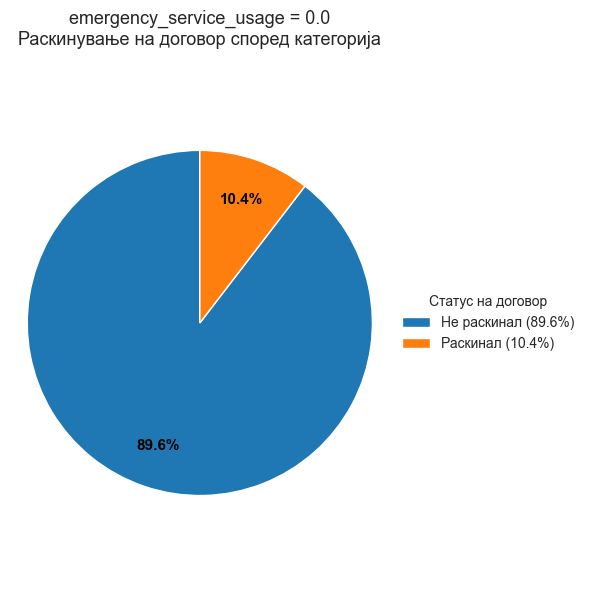

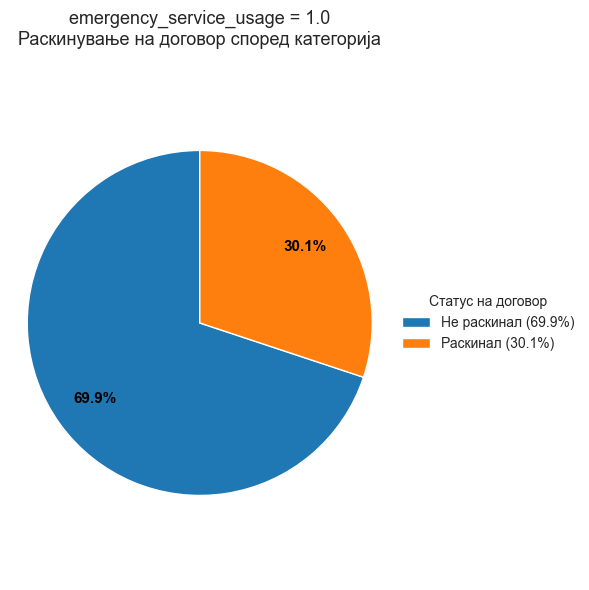

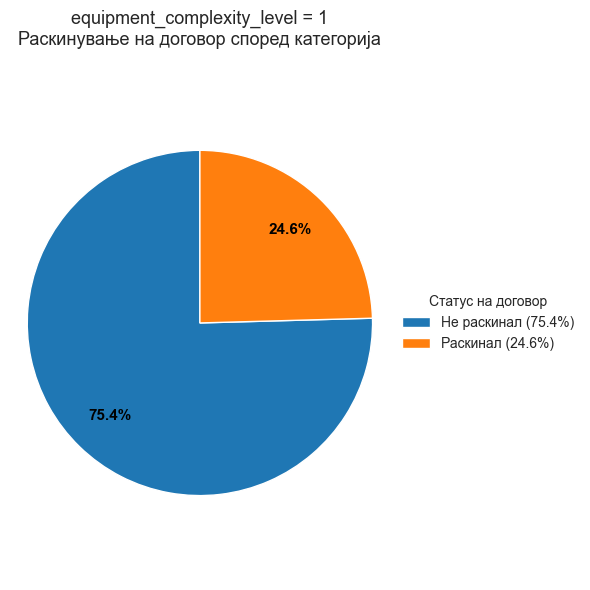

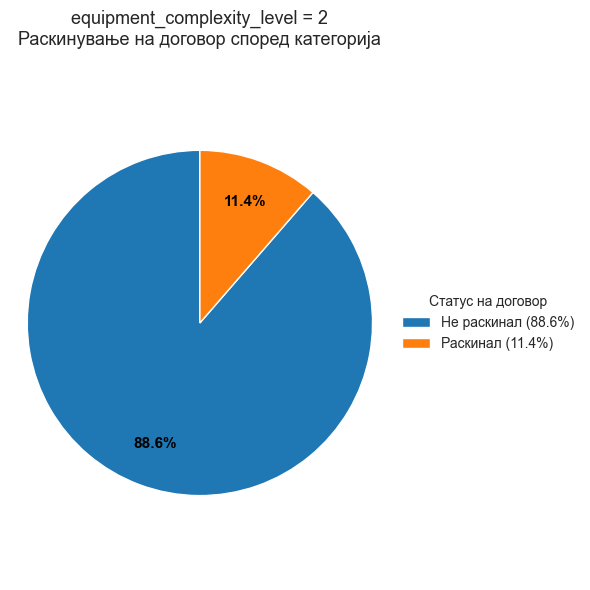

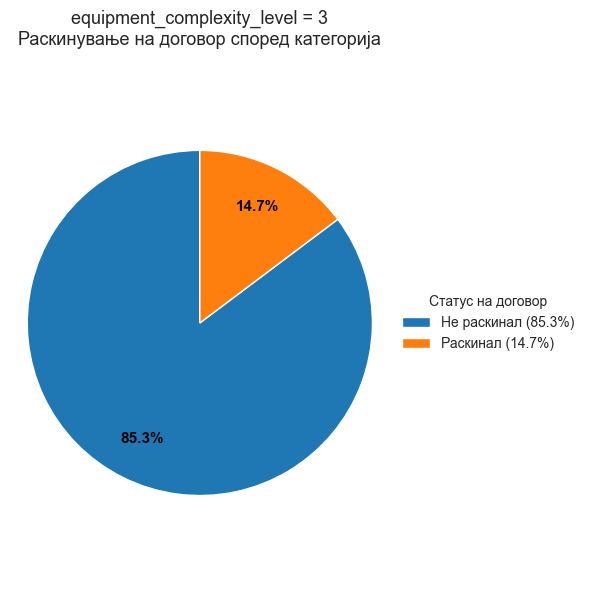

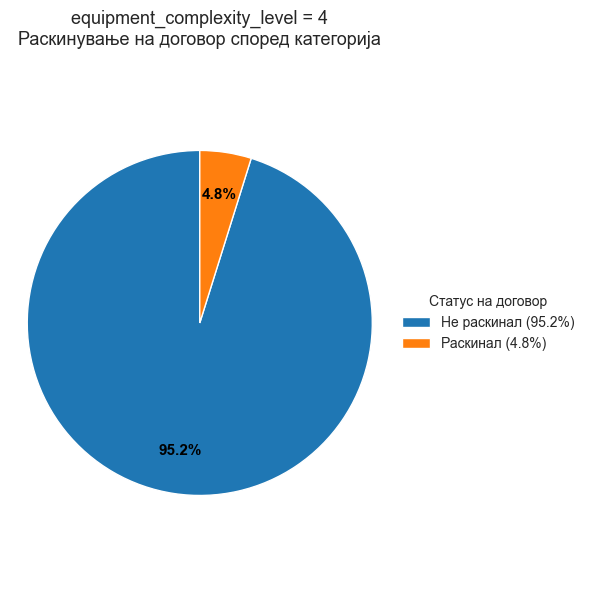

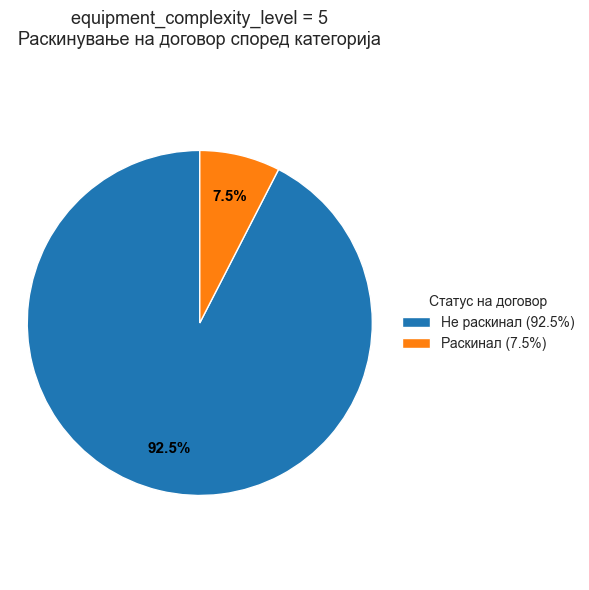

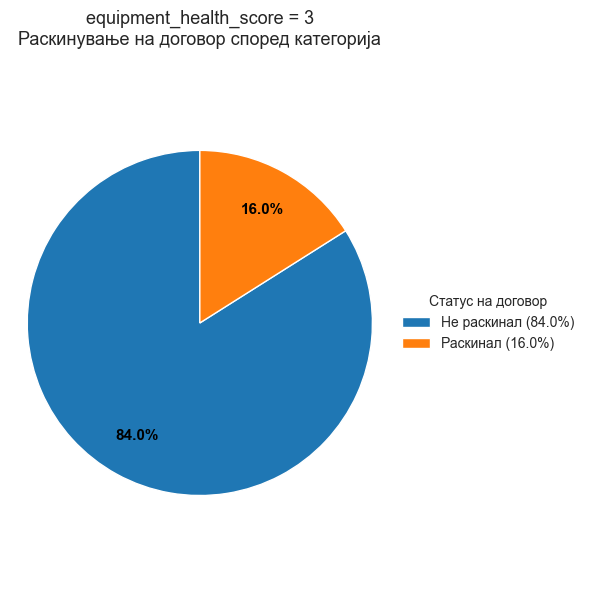

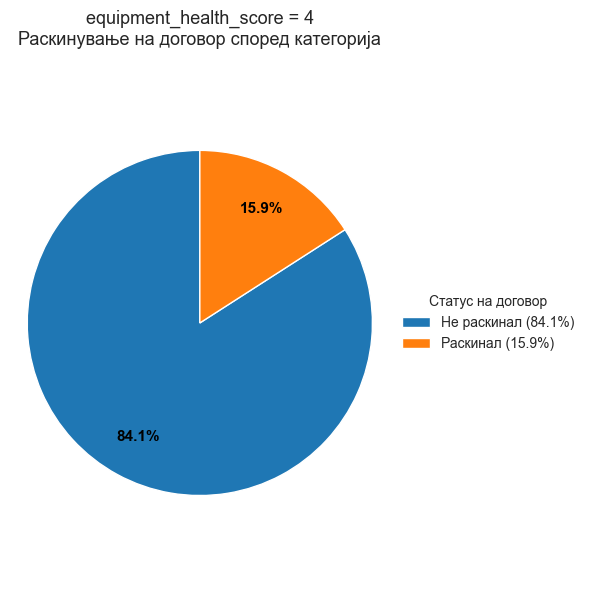

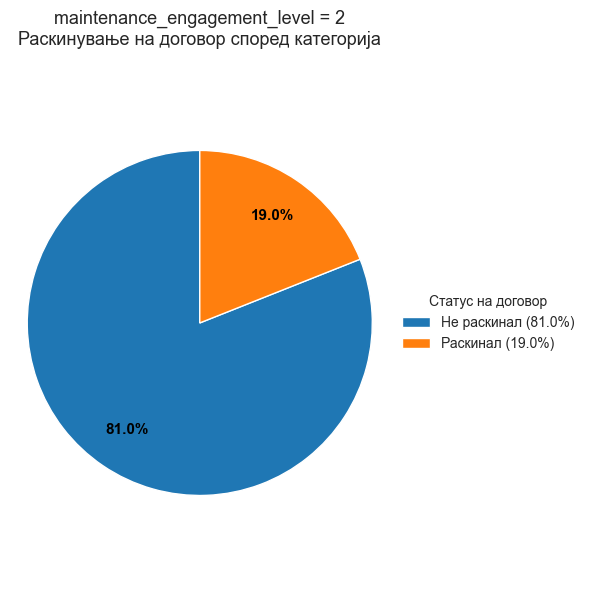

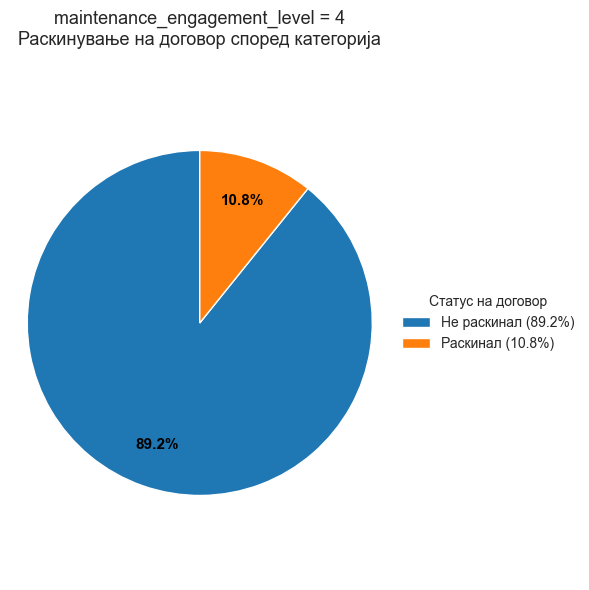

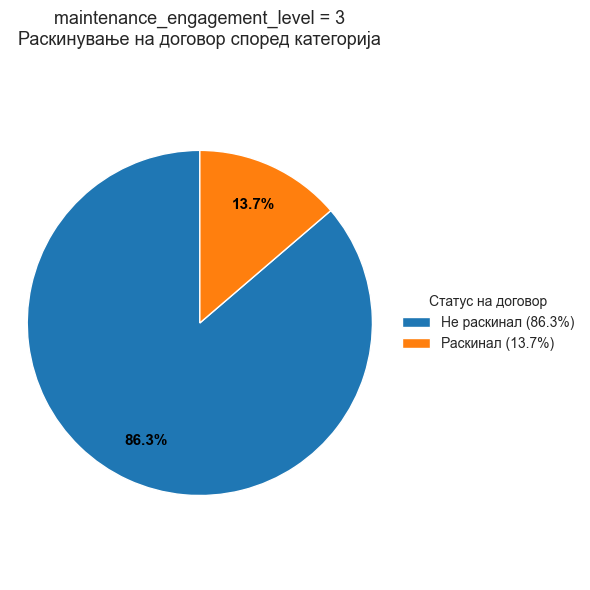

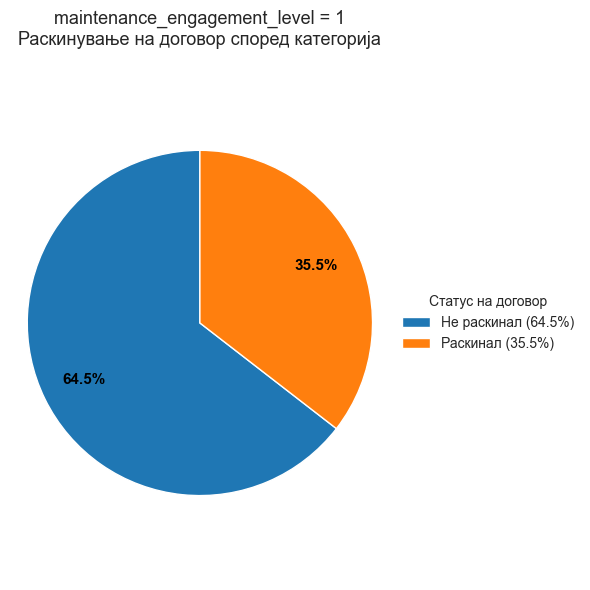

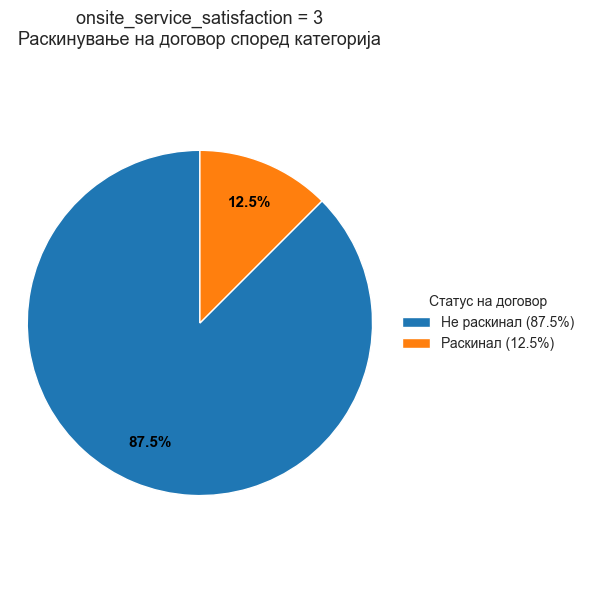

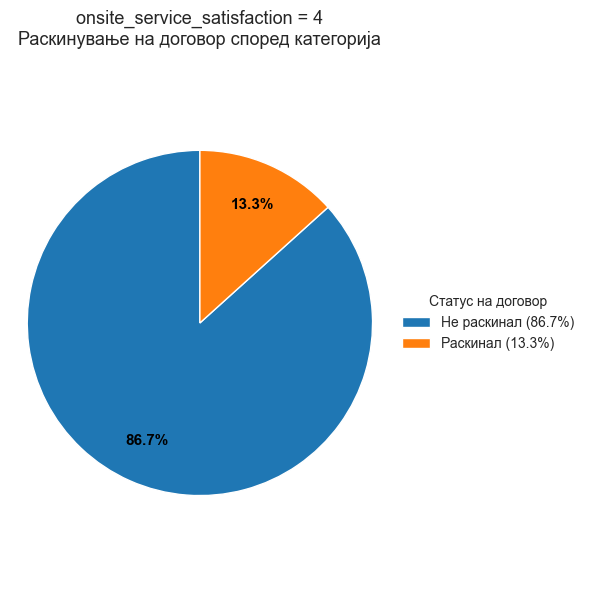

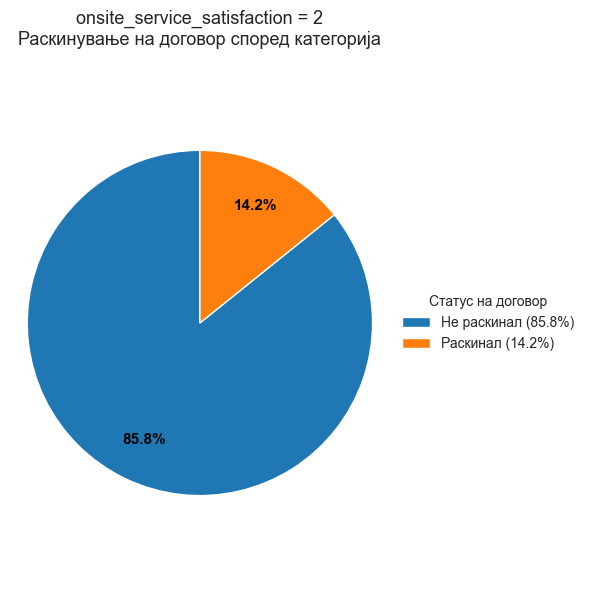

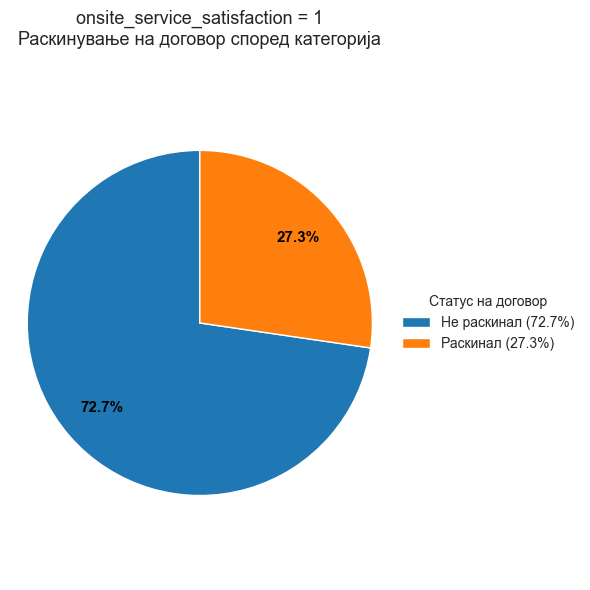

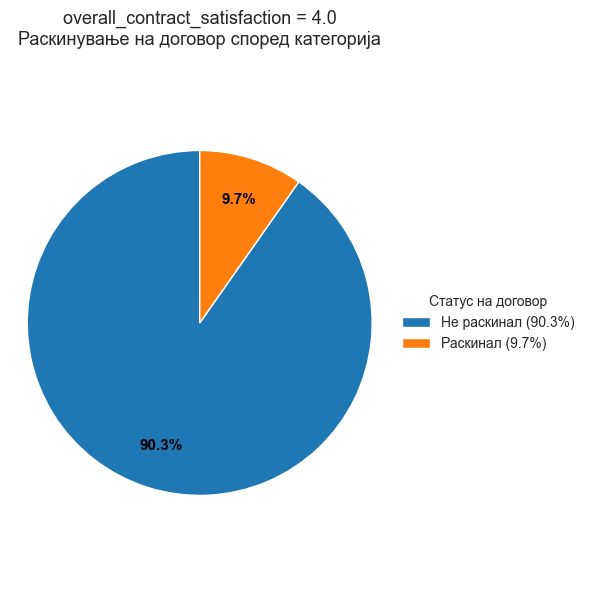

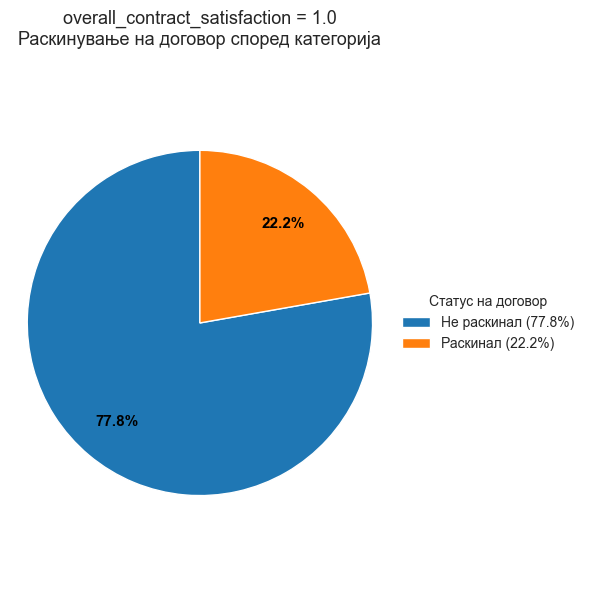

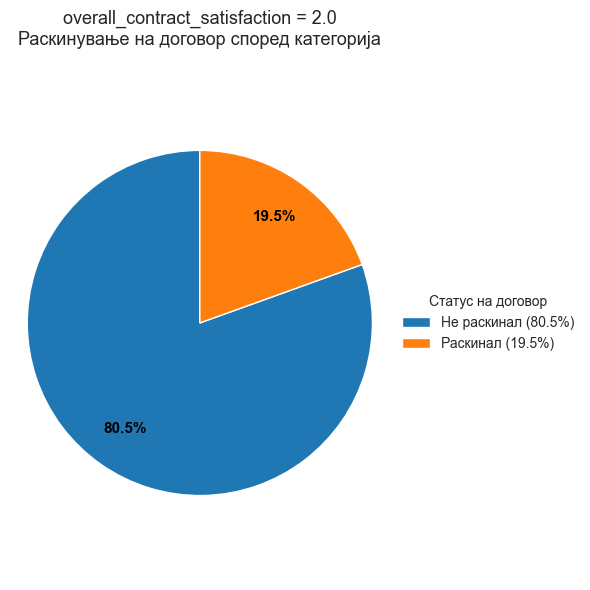

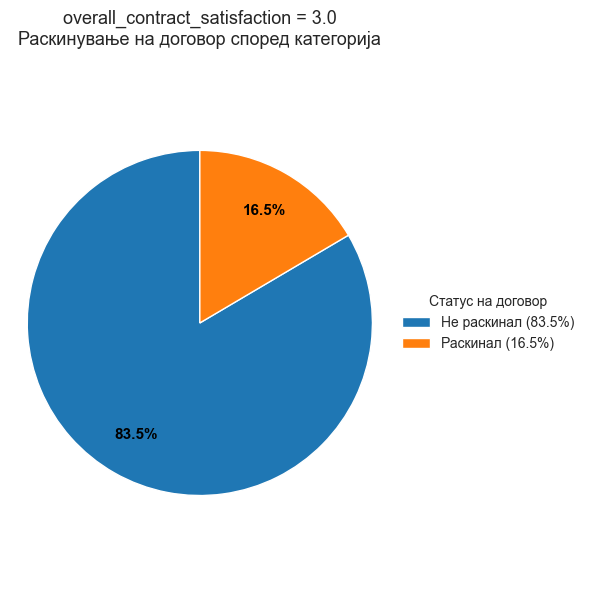

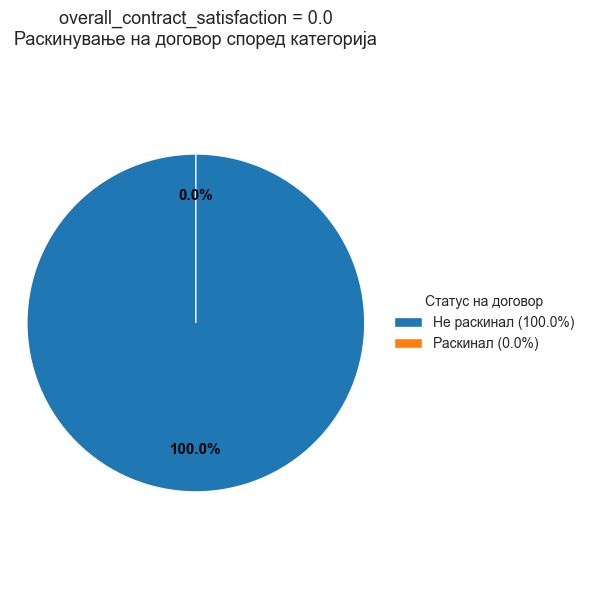

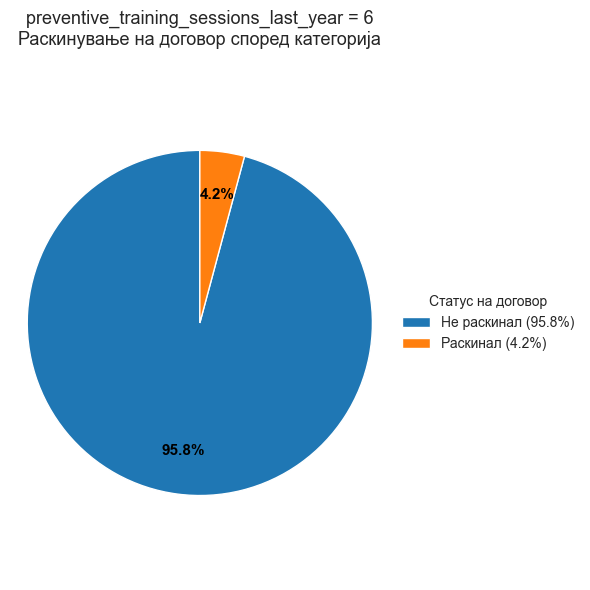

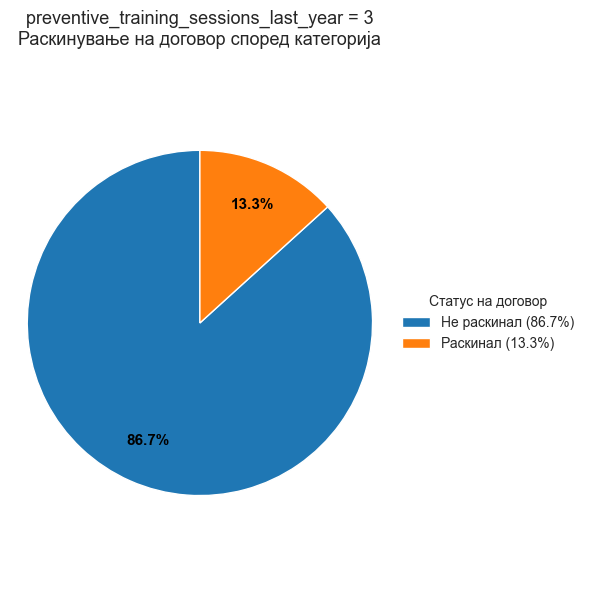

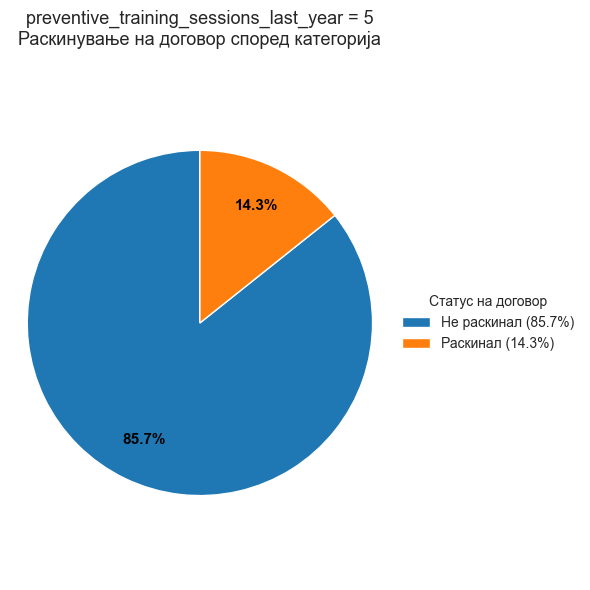

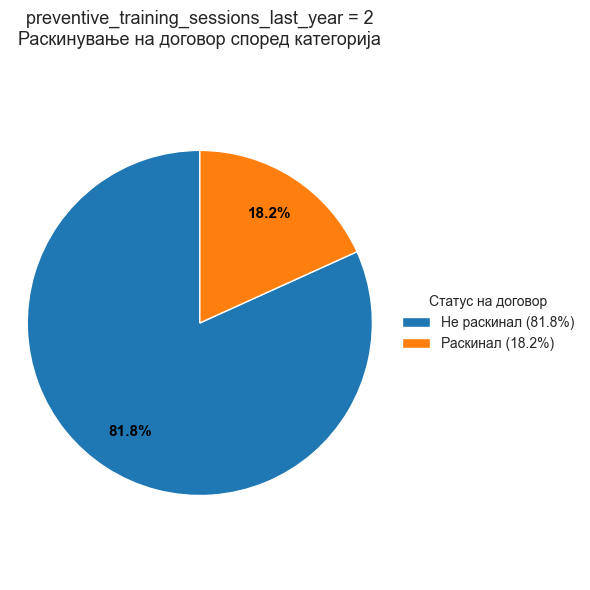

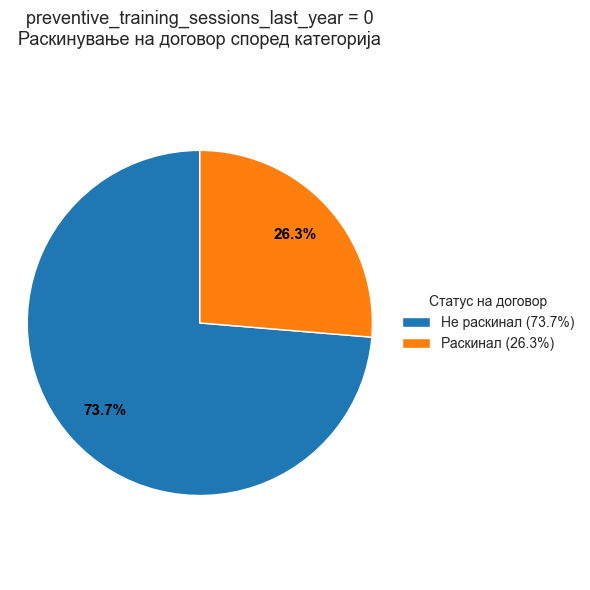

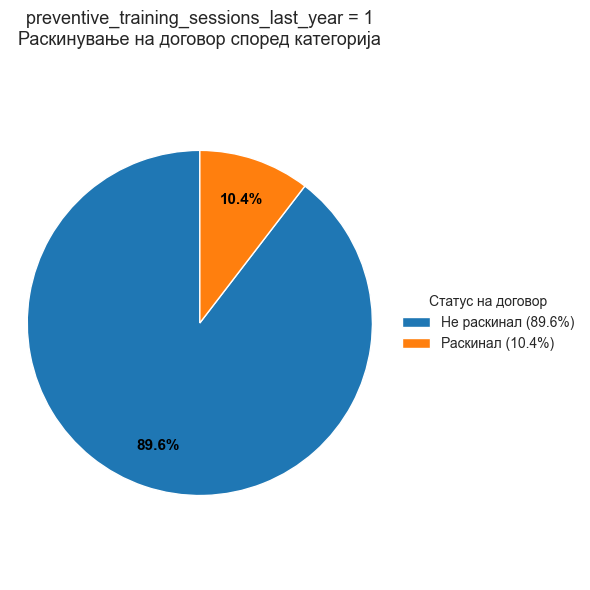

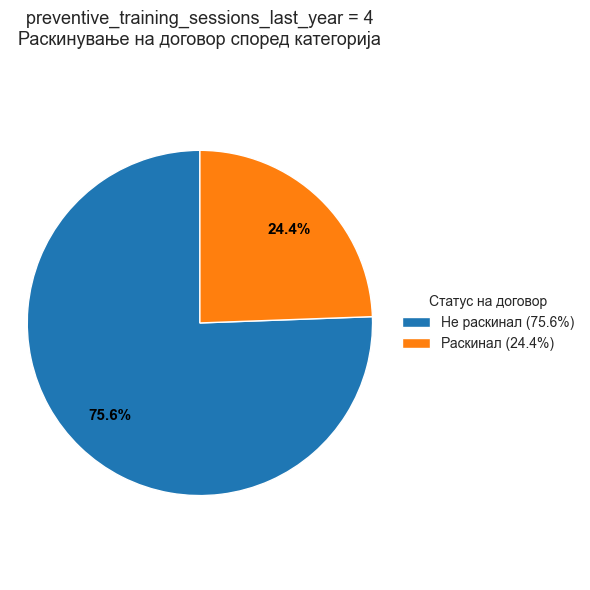

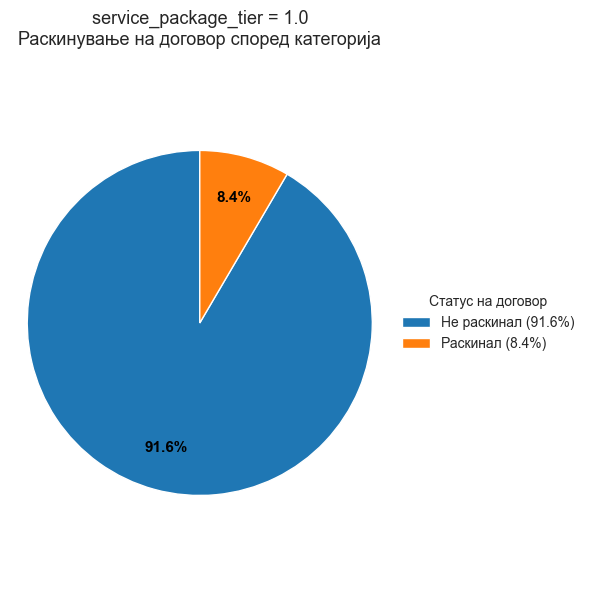

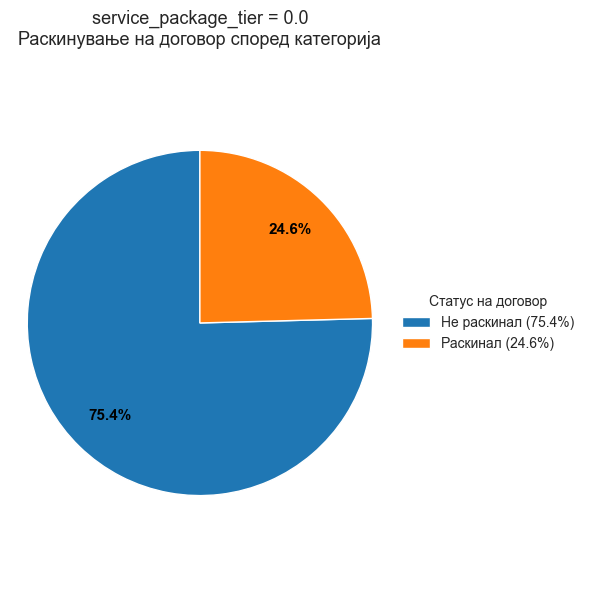

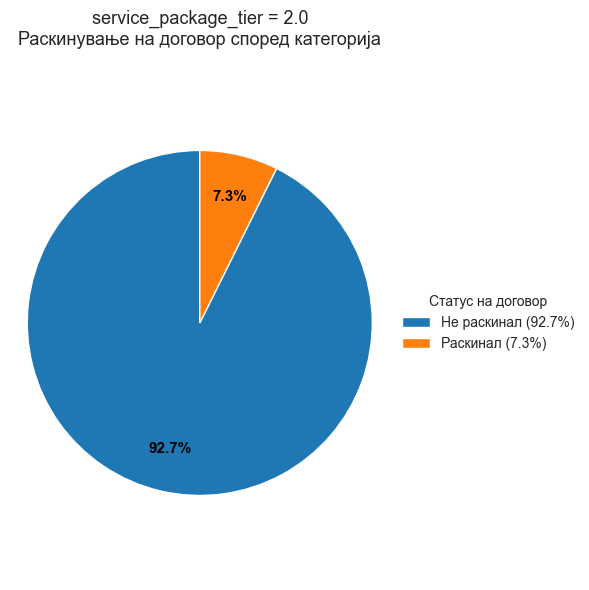

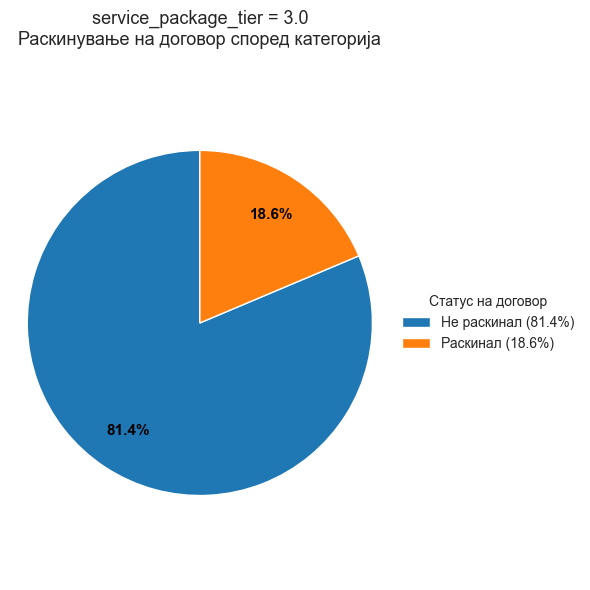

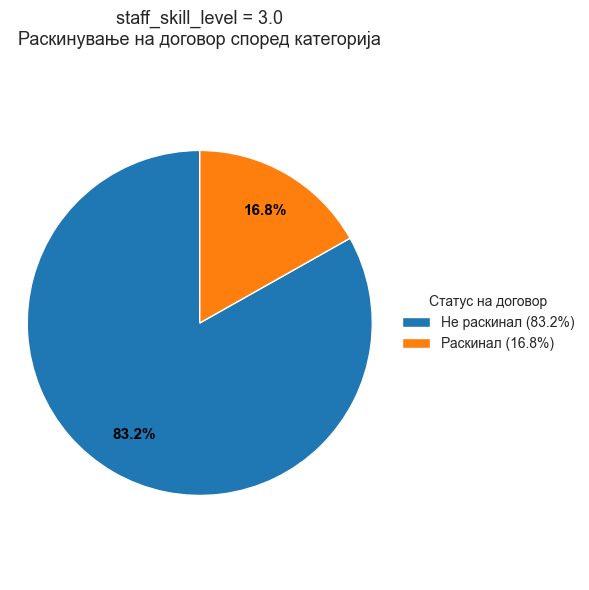

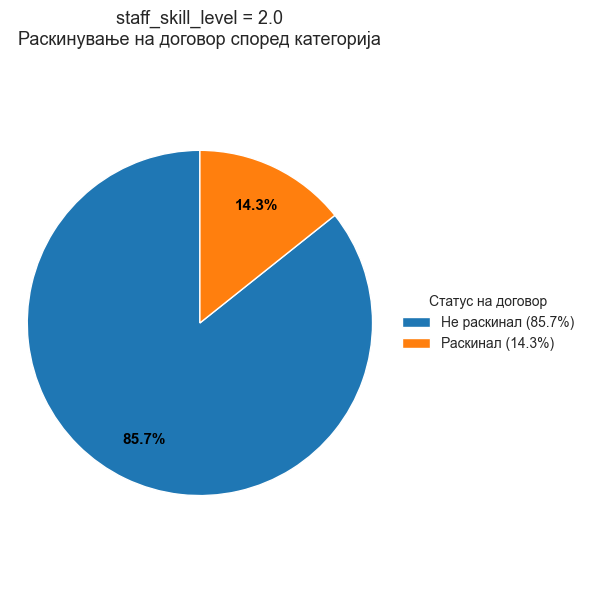

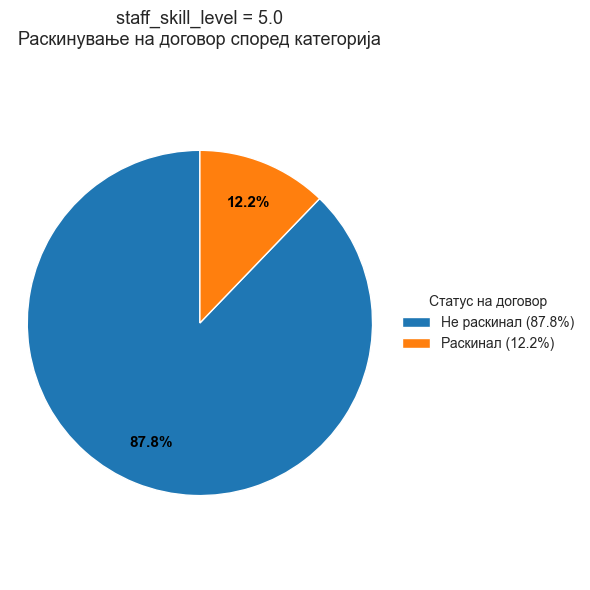

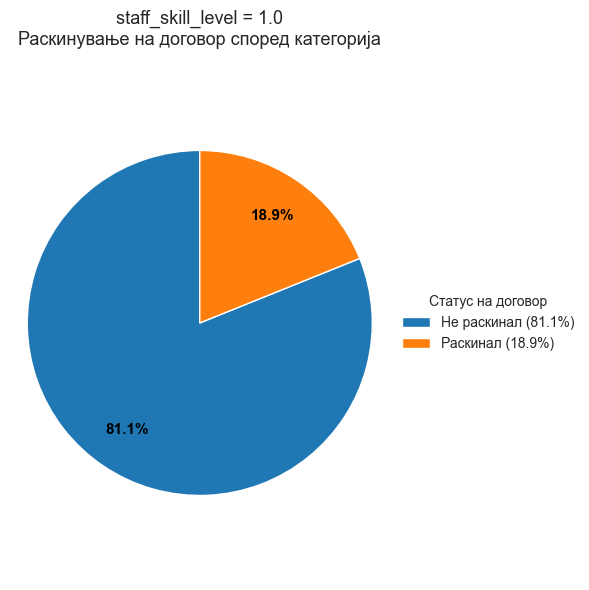

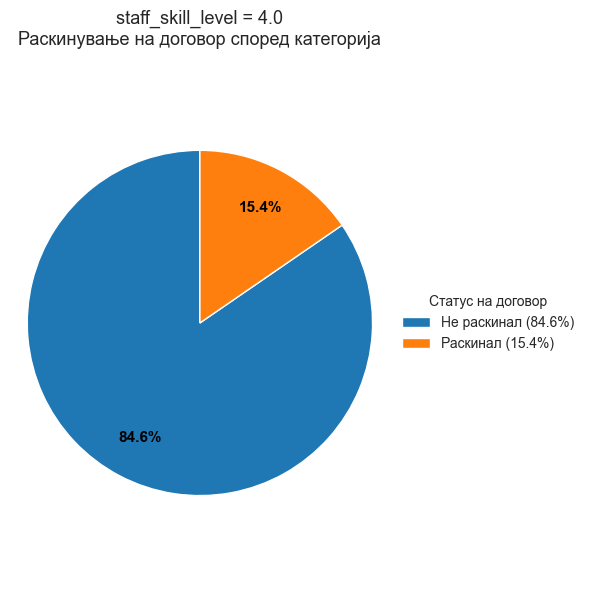

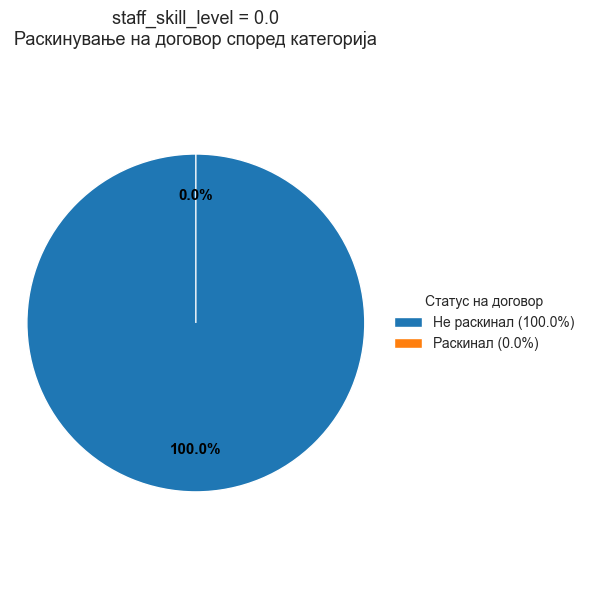

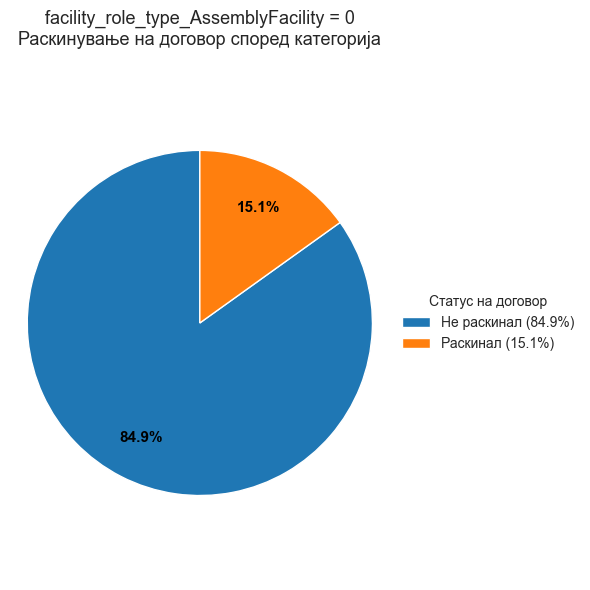

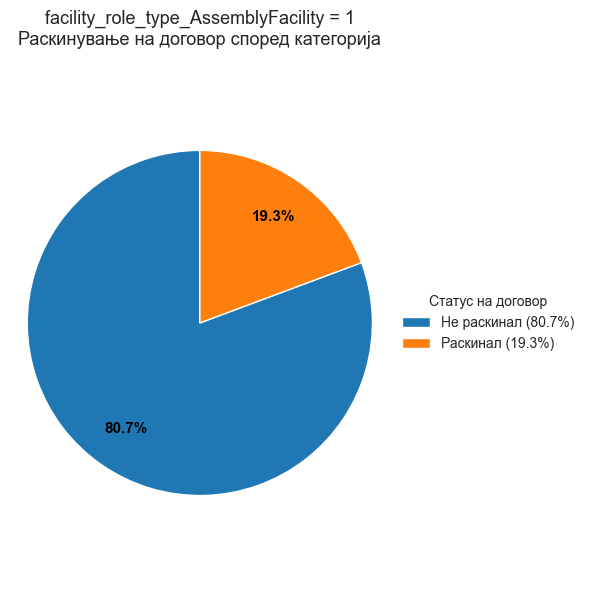

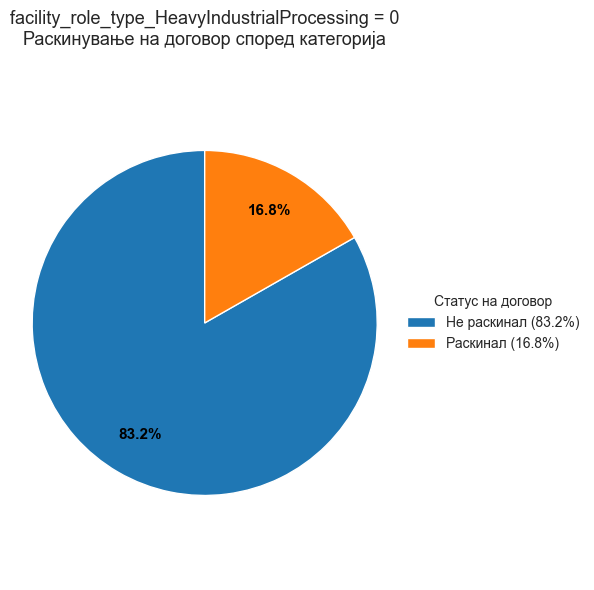

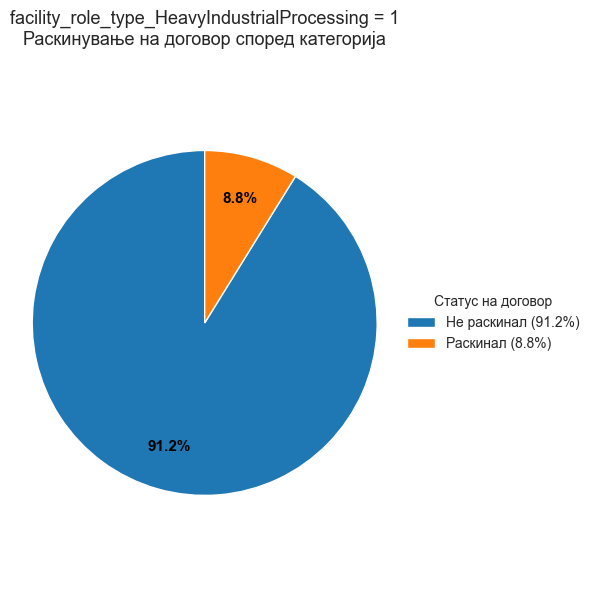

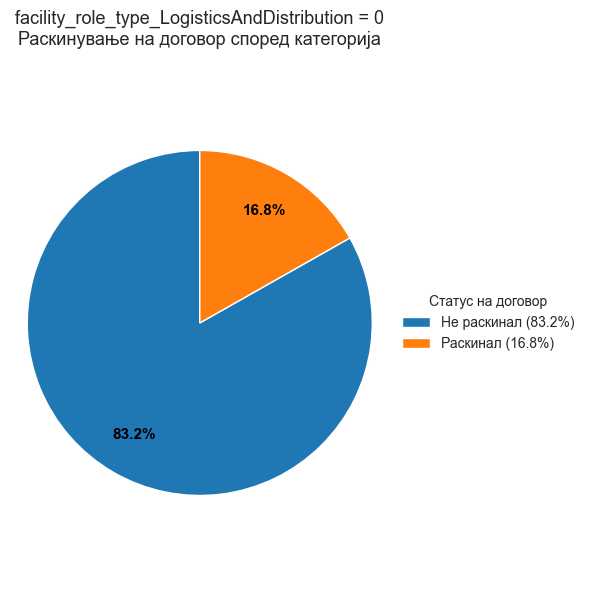

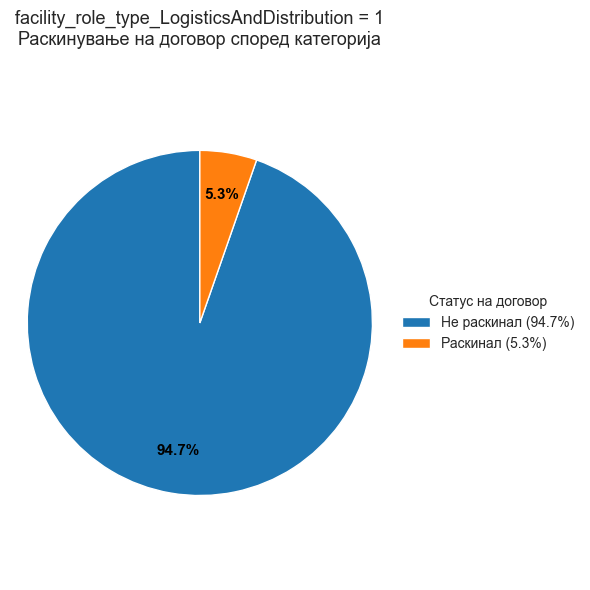

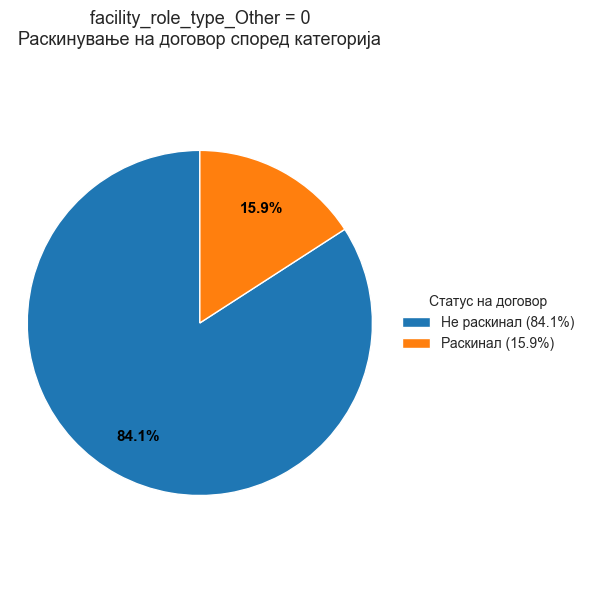

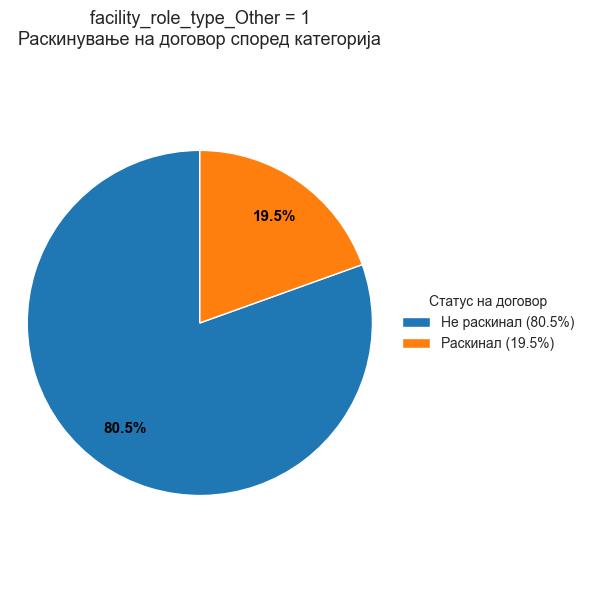

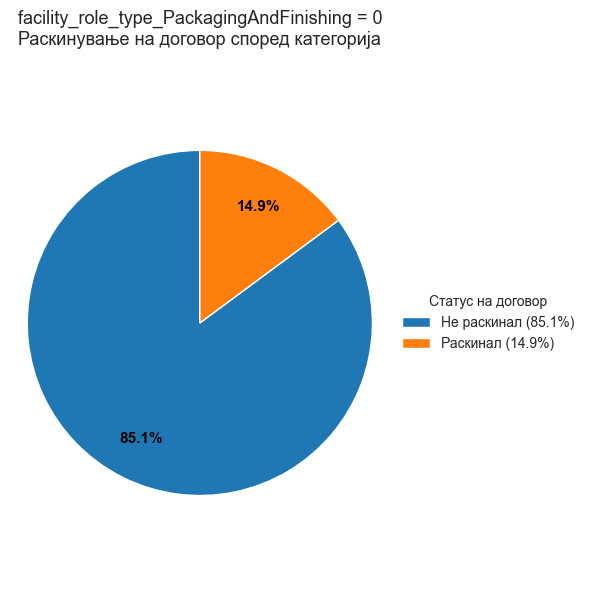

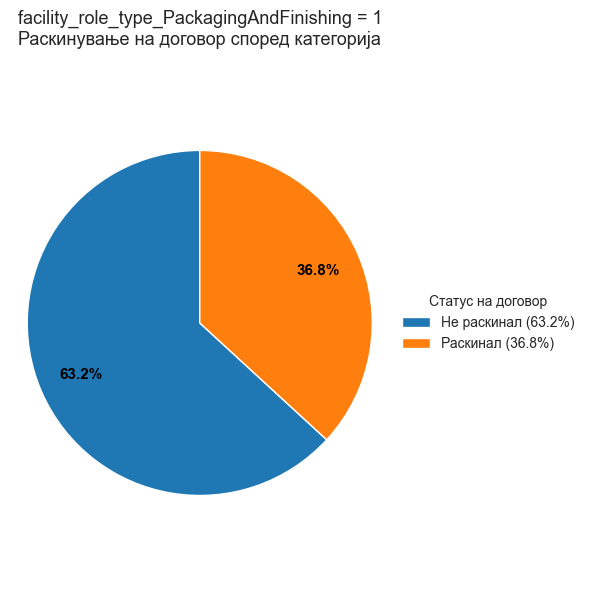

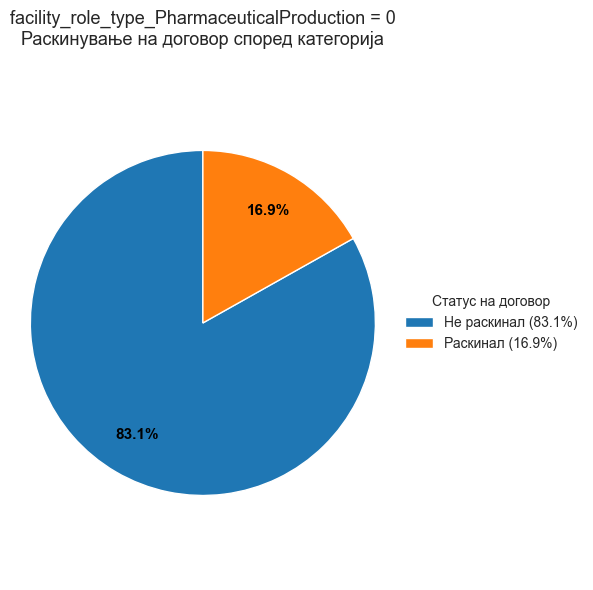

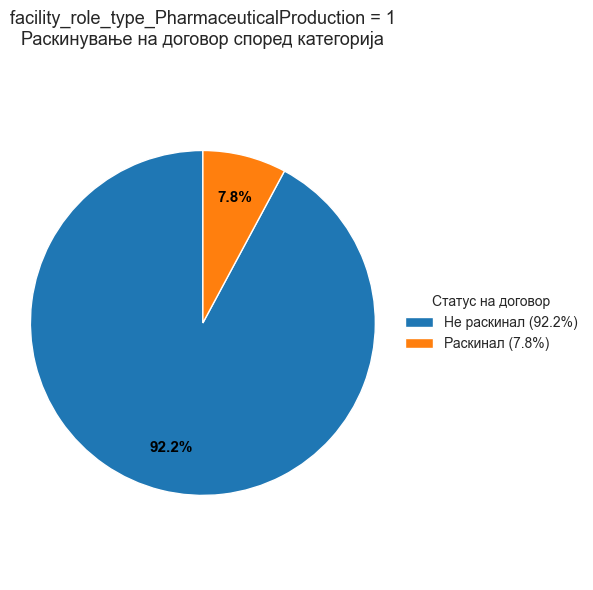

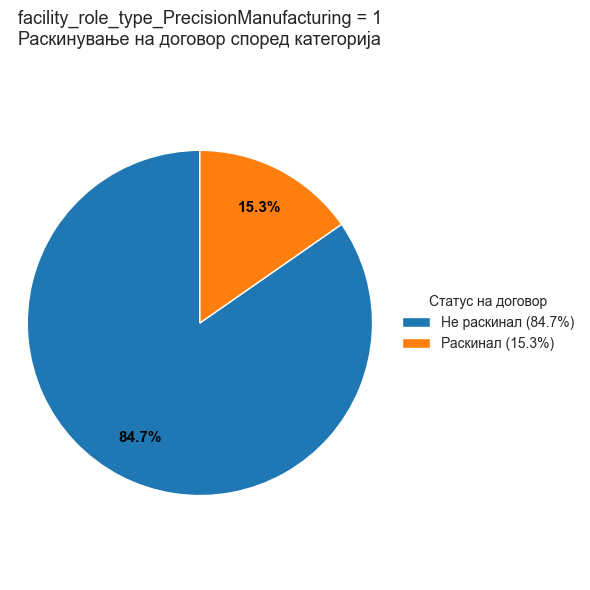

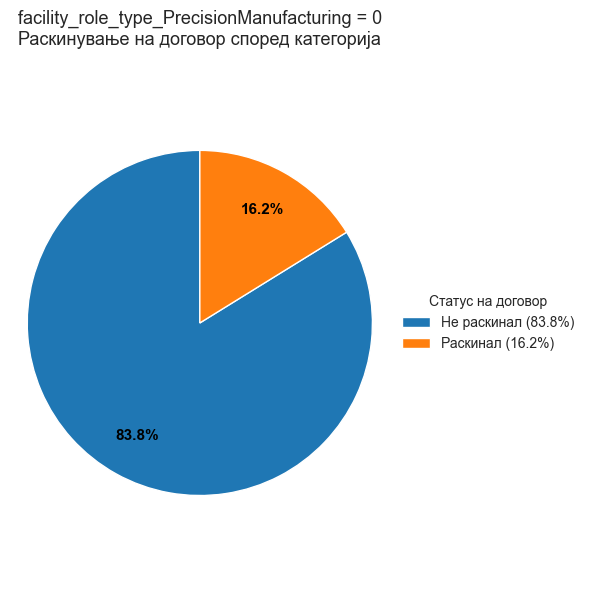

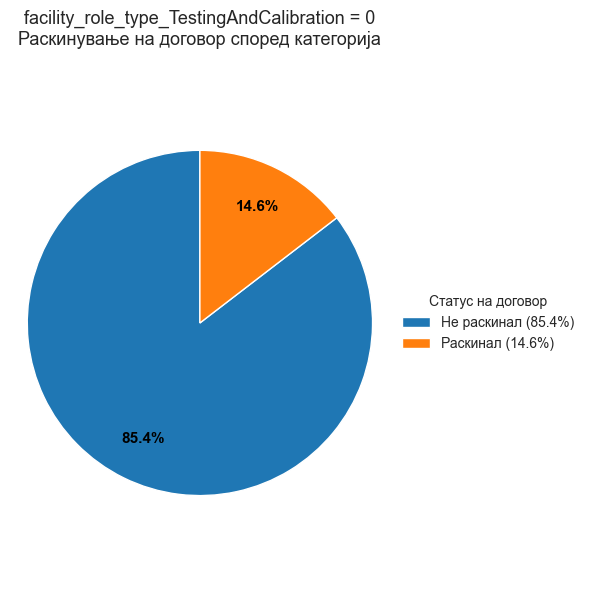

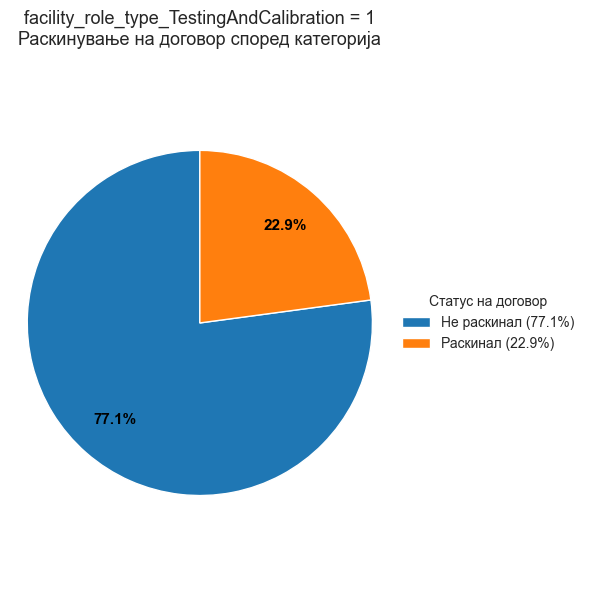

In [62]:

cols = [
    'emergency_service_usage',
    'equipment_complexity_level',
    'equipment_health_score',
    'maintenance_engagement_level',
    'onsite_service_satisfaction',
    'overall_contract_satisfaction',
    'preventive_training_sessions_last_year',
    'service_package_tier',
    'staff_skill_level',
    'facility_role_type_AssemblyFacility',
    'facility_role_type_HeavyIndustrialProcessing',
    'facility_role_type_LogisticsAndDistribution',
    'facility_role_type_Other',
    'facility_role_type_PackagingAndFinishing',
    'facility_role_type_PharmaceuticalProduction',
    'facility_role_type_PrecisionManufacturing',
    'facility_role_type_TestingAndCalibration'
]

for col in cols:
    if col not in data_encoded.columns:
        print(f"Колоната '{col}' не постои.")
        continue

    for val in data_encoded[col].unique():

        subset = data_encoded[data_encoded[col] == val]
        if subset.empty:
            continue

        counts = subset['contract_terminated'].value_counts()
        pct = counts / counts.sum() * 100

        sizes = [
            pct.get(0, 0),
            pct.get(1, 0)
        ]

        labels = [
            f"Не раскинал ({pct.get(0, 0):.1f}%)",
            f"Раскинал ({pct.get(1, 0):.1f}%)"
        ]

        # --- Improved Plot ---
        fig, ax = plt.subplots(figsize=(6, 6))

        wedges, texts, autotexts = ax.pie(
            sizes,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.75,     # move percentages slightly inward
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        )

        # Move labels outside
        ax.legend(
            wedges, labels,
            title="Статус на договор",
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize=10
        )

        plt.setp(autotexts, size=11, weight="bold", color="black")

        ax.set_title(
            f"{col} = {val}\nРаскинување на договор според категорија",
            fontsize=13,
            pad=15
        )

        ax.axis('equal')  # circle shape
        plt.tight_layout()
        plt.show()


За питите кои се 0%, или не постои или постои многу мал број на такви податоци.

In [63]:
results = []

for col in cols:
    if col not in data_encoded.columns:
        print(f"Колоната '{col}' не постои.")
        continue
    
    for val in sorted(data_encoded[col].unique()):
        subset = data_encoded[data_encoded[col] == val]

        if subset.empty:
            continue

        # Пресметај процент на раскинати
        pct_terminated = subset['contract_terminated'].mean() * 100

        results.append({
            "Колона": col,
            "Вредност": val,
            "% Раскинати": round(pct_terminated, 2)
        })

# Финалната табела
results_df = pd.DataFrame(results)
results_df


,Колона,Вредност,% Раскинати
0,emergency_service_usage,0.0,10.42
1,emergency_service_usage,1.0,30.10
2,equipment_complexity_level,1.0,24.56
3,equipment_complexity_level,2.0,11.36
4,equipment_complexity_level,3.0,14.74
5,equipment_complexity_level,4.0,4.82
6,equipment_complexity_level,5.0,7.55
7,equipment_health_score,3.0,16.03
8,equipment_health_score,4.0,15.91
9,maintenance_engagement_level,1.0,35.48


Клиентите кои користат итни сервиси имаат околу три пати поголема веројатност да го прекинат договорот во споредба со оние што не ги користат, што укажува на проблеми со опремата или незадоволство од услугата. Сложеноста на опремата исто така игра значајна улога: најниското ниво на сложеност е поврзано со највисока стапка на раскинување, додека повисоките нивоа (4 и 5) имаат многу ниска стапка, што може да се должи на понови системи или подобри пакети за одржување.

Состојбата на опремата (health score) не покажува големи разлики меѓу категориите и не претставува силен предиктор. Од друга страна, ангажманот за одржување е критично важен: клиентите со најниско ниво на ангажман имаат највисока стапка на раскинување (над 35%), додека повисоките нивоа значително ја намалуваат веројатноста за прекин.

Задоволството од сервисот е исто така релевантно – незадоволните клиенти имаат двојно поголема шанса да го раскинат договорот. Вкупното задоволство од договорот логично корелира со задржувањето: колку е пониско задоволството, толку е поголема веројатноста за напуштање, додека најзадоволните клиенти имаат најниска стапка на раскинување.

Превентивните тренинзи играат значајна улога: клиентите без тренинзи имаат најголема стапка на раскинување, додека оние со повеќе тренинзи (особено пет или шест) покажуваат многу поголема стабилност. Сервисниот пакет исто така е важен фактор – најевтиниот пакет има најмногу раскинувања, додека премиум пакетите имаат најниска стапка.

Вештината на персоналот влијае врз задржувањето: повисоката вештина ја намалува веројатноста за раскинување, додека ниските нивоа се поврзани со поголем ризик. Типот на погон исто така е значаен: клиенти од секторот „Packaging and Finishing“ имаат највисока стапка на раскинување, додека „Logistics and Distribution“ и „Pharma“ погони се најстабилни.

Во целина, најголем ризик од раскинување имаат клиентите со низок ангажман за одржување, оние што користат итни сервиси, незадоволни од договорот во целина, клиенти со малку или без превентивни тренинзи, како и оние со најевтин пакет или од секторот „Packaging“. Од друга страна, најстабилни се клиентите со премиум пакети, логистички и фармацевтски погони, висока вештина на персоналот и редовни тренинзи.

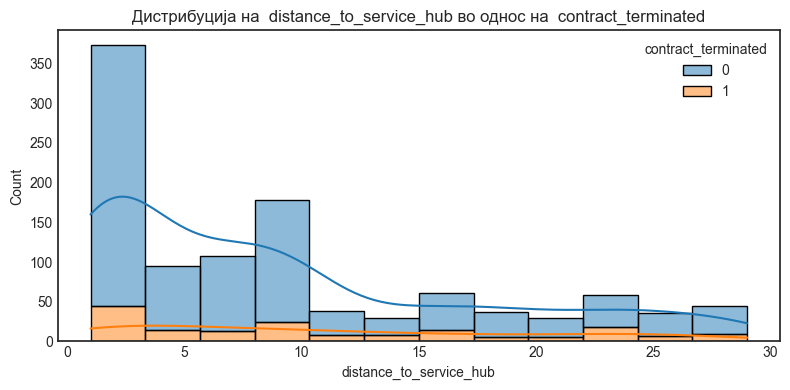

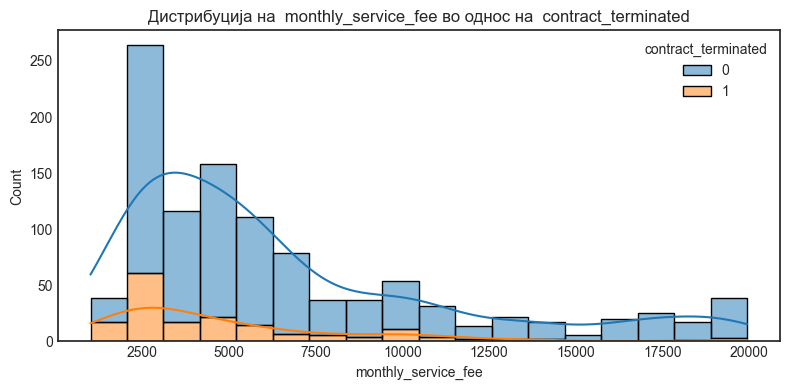

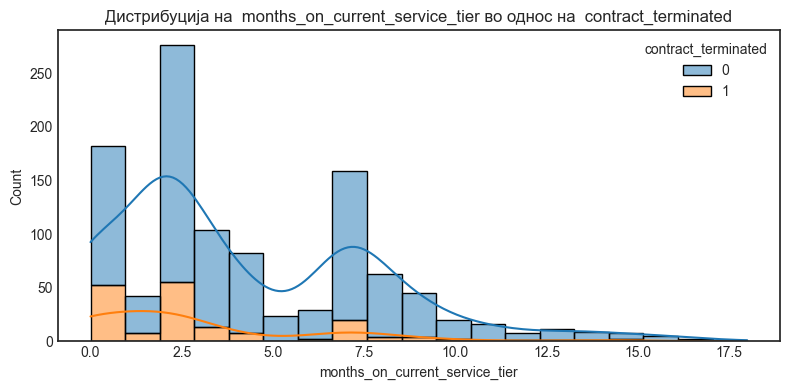

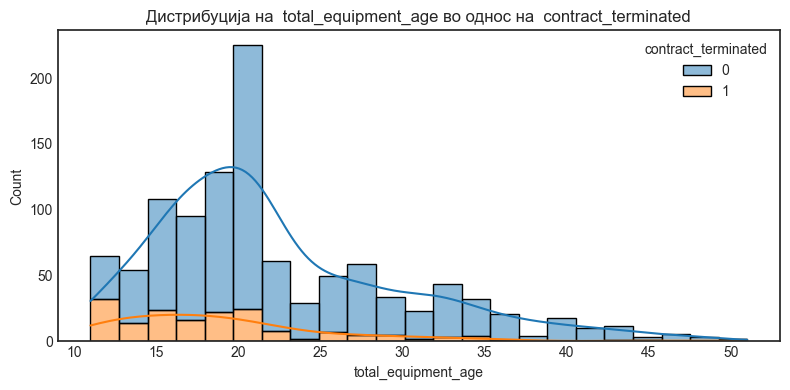

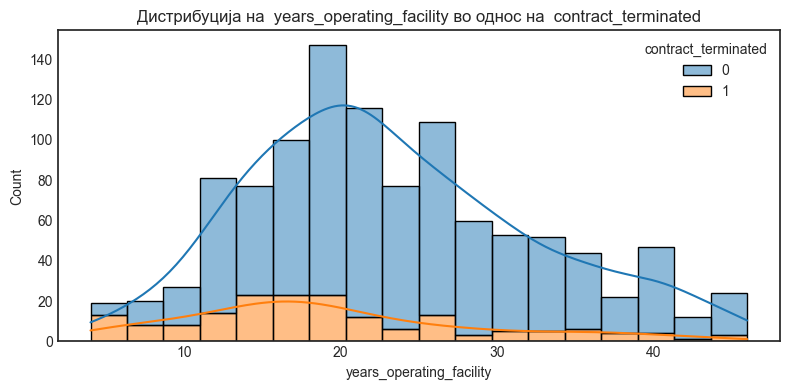

In [64]:
features = ['distance_to_service_hub', 'monthly_service_fee', 'months_on_current_service_tier', 
              'total_equipment_age', 'years_operating_facility']

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=data_encoded, x=feature, hue='contract_terminated', kde=True, multiple='stack')
    plt.title(f'Дистрибуција на  {feature} во однос на  contract_terminated')
    plt.tight_layout()
    plt.show()

1. График 1 - distance_to_service_hub
    Графикот ја прикажува распределбата на растојанието до сервисниот хаб во зависност од тоа дали договорот е раскинат или не. Од визуелизацијата може да се заклучи дека клиентите со нераскинати договори (прикажани со сина боја) најчесто се наоѓаат на растојание помало од пет единици, при што бројот на записи постепено опаѓа со зголемување на растојанието. Клиентите со раскинати договори (прикажани со портокалова боја) исто така покажуваат тенденција на намалување на бројот на записи со зголемување на растојанието, но нивната бројност е значително помала во споредба со групата на нераскинати договори.Хистограмот укажува дека најголемиот дел од клиентите кои остануваат со активен договор се концентрирани блиску до сервисниот хаб, додека само мал дел од клиентите кои го раскинале договорот се наоѓаат во овој опсег. Кривата за двете категории дополнително потврдува дека растојанието до хабот најчесто е ниско, со нагло намалување на бројот на примероци како растојанието расте.

2. График 2 - monthly_service_fee
    Од визуелизацијата може да се заклучи дека клиентите со активни договори (прикажани со сина боја) најчесто плаќаат месечна околу 2500$ , што претставува најчеста вредност за оваа категорија. Со зголемување на месечната такса бројот на записи значително опаѓа, што укажува дека повисоките износи се поретки кај задржаните клиенти.Кај клиентите со раскинати договори (прикажани со портокалова боја) се забележува дека месечните такси се повеќе концентрирани во интервалот меѓу 2500 и 5000$ , но нивната бројност е значително помала во споредба со групата на нераскинати договори. Хистограмот потврдува дека најголем дел од корисниците со активни договори имаат такса околу 2500, додека кај раскинатите договори распределбата е поширока и се протега кон повисоки вредности. Кривата дополнително покажува дека за нераскинатите договори густината е концентрирана во пониските износи, додека кај раскинатите е многу пониска и се шири кон повисоки износи.

3. График 3- months_on_current_service_tier
    Од визуелизацијата може да се заклучи дека поголемиот дел од клиентите со активни договори (прикажани со сина боја) имаат поминато краток период на тековниот сервисен план, најчесто во интервалот од нула до два месеци. Како што времетраењето на користењето расте, бројот на клиенти со нераскинати договори постепено се намалува.Кај клиентите со раскинати договори (прикажани со портокалова боја) се забележува дека најголем дел од нив исто така се концентрирани во првите два месеци од користењето на услугата, што укажува дека раскинувањето најчесто се случува многу рано по започнувањето. Сепак, нивната бројност е значително помала во споредба со групата на нераскинати договори, што се гледа и од пониската густина на кривата.Оваа анализа укажува дека раната фаза на користење е критична за задржување на клиентите, а соодветна поддршка и ангажман во првите месеци може значително да ја намали веројатноста за раскинување на договорите.

4. График 4- total_equipment_age
        Анализата покажува дека најголемиот дел од клиентите со активни договори имаат опрема стара помеѓу 15 и 25 години, со најголема концентрација околу 20 години. Како што староста на опремата се зголемува, бројот на клиенти со нераскинати договори постепено опаѓа.Кај клиентите со раскинати договори, опремата најчесто е стара помеѓу 15 и 30 години, но нивната бројност е значително помала во споредба со групата на нераскинати договори. Дополнително, со зголемување на староста на опремата бројот на раскинати договори уште повеќе се намалува, што укажува дека најголем дел од прекините се случуваат кај опрема со средна старост, додека кај многу стара опрема (над 30 години) бројот на раскинувања е релативно низок. 

5. График 5- years_operating_facility
    Анализата покажува дека најголемиот дел од клиентите со активни договори имаат објекти кои функционираат помеѓу 15 и 25 години, при што токму овој интервал доминира во повеќето опсези. Како што бројот на години на работа се зголемува, бројот на клиенти со нераскинати договори постепено се намалува.Кај клиентите со раскинати договори се забележува слична тенденција: најголем дел од нив исто така имаат објекти со работно време помеѓу 15 и 25 години, но нивната бројност е значително помала во споредба со групата на нераскинати договори. Со зголемување на годините на работа, бројот на раскинати договори дополнително опаѓа, што укажува дека прекините најчесто се случуваат кај објекти со среден период на функционирање.Заклучокот од оваа анализа е дека клиентите со помалку години на работа на објектот имаат поголема веројатност да го раскинат договорот, додека оние со подолг период на функционирање имаат поголема стабилност и тенденција да го продолжат договорот. Сепак, најголемиот број на случаи – и на раскинати и на нераскинати договори – се концентрирани кај објекти со старост помеѓу 15 и 25 години.

## Стандардизација

Извор за одбраната стандардизација- https://www.kaggle.com/code/discdiver/guide-to-scaling-and-standardizing
https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/

Избран е StandardScaler затоа што оваа техника овозможува податоците да бидат стабилни и споредливи меѓу себе. Со негова примена сите карактеристики добиваат еднаква тежина во класификацискиот модел, без разлика дали првично имаат различни единици или опсези на вредности. На тој начин се избегнува ризикот некоја променлива со големи бројки да го искриви резултатот и да доминира над останатите.Дополнително, StandardScaler создава услови кои се најпогодни за алгоритмите што претпоставуваат нормална распределба на податоците, како што се логистичка регресија, SVM или невронски мрежи. Со тоа се обезбедува моделот да работи поефикасно, да дава попрецизни резултати и да биде полесен за интерпретација.






In [65]:
data_standardized=data_encoded.copy()

In [66]:
numeric_cols = data_standardized.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['ID',
 'contract_terminated',
 'distance_to_service_hub',
 'downtime_tolerance',
 'emergency_service_usage',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'monthly_service_fee',
 'months_on_current_service_tier',
 'months_with_provider',
 'num_prior_providers',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'preventive_training_sessions_last_year',
 'service_package_tier',
 'staff_skill_level',
 'total_equipment_age',
 'years_operating_facility',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration']

In [67]:
binary_cols = [col for col in numeric_cols if set(data_standardized[col].unique()) <= {0, 1,2,3,4,5}]
binary_cols

['contract_terminated',
 'downtime_tolerance',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'staff_skill_level',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration']

In [68]:
numeric_set = set(numeric_cols)
binary_set = set(binary_cols)
cols_to_scale_set = numeric_set - binary_set
cols_to_scale = ['distance_to_service_hub', 'monthly_service_fee', 'months_on_current_service_tier', 'months_with_provider', 'total_equipment_age', 'years_operating_facility']

In [69]:
scaler = StandardScaler()
data_standardized[cols_to_scale] = scaler.fit_transform(data_standardized[cols_to_scale])

In [70]:
data_standardized.describe()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,...,total_equipment_age,years_operating_facility,facility_role_type_AssemblyFacility,facility_role_type_HeavyIndustrialProcessing,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration
count,1087.000000,1087.000000,1.087000e+03,1087.000000,1086.000000,1087.000000,1087.000000,1087.000000,1.087000e+03,1.087000e+03,...,1.087000e+03,1.087000e+03,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,544.000000,0.160074,-9.478261e-17,2.760810,0.284530,2.075437,3.161914,2.727691,7.517241e-17,8.170915e-17,...,-1.438081e-16,-1.225637e-16,0.214351,0.093836,0.068997,0.037718,0.052438,0.093836,0.204232,0.172953
std,313.934176,0.366843,1.000460e+00,0.701098,0.451398,1.118163,0.368541,0.707365,1.000460e+00,1.000460e+00,...,1.000460e+00,1.000460e+00,0.410561,0.291735,0.253566,0.190602,0.223011,0.291735,0.403325,0.378381
min,1.000000,0.000000,-1.013815e+00,1.000000,0.000000,1.000000,3.000000,1.000000,-1.170188e+00,-1.156707e+00,...,-1.475145e+00,-2.105065e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.500000,0.000000,-8.903394e-01,2.000000,0.000000,1.000000,3.000000,2.000000,-7.682942e-01,-6.047579e-01,...,-6.949881e-01,-6.711448e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,544.000000,0.000000,-2.729632e-01,3.000000,0.000000,2.000000,3.000000,3.000000,-3.335114e-01,-3.287832e-01,...,-1.748834e-01,-1.196371e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,815.500000,0.000000,5.913635e-01,3.000000,1.000000,3.000000,3.000000,3.000000,4.263896e-01,7.751158e-01,...,4.752475e-01,6.524737e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1087.000000,1.000000,2.443492e+00,4.000000,1.000000,5.000000,4.000000,4.000000,2.796170e+00,3.810838e+00,...,3.725902e+00,2.527600e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
data_standardized=data_standardized.drop('ID',axis=1)

#### За второ најдобро решение

In [72]:
data_resenie1_std=data_resenie1.copy()

In [73]:
numeric_cols = data_resenie1_std.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['ID',
 'contract_terminated',
 'distance_to_service_hub',
 'downtime_tolerance',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'monthly_service_fee',
 'months_on_current_service_tier',
 'months_with_provider',
 'num_prior_providers',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'preventive_training_sessions_last_year',
 'staff_skill_level',
 'total_equipment_age',
 'years_operating_facility',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration',
 'service_package_tier_Bronze',
 'service_package_tier_Enterprise',
 'service_package_tier_Gold',
 'service_package_tier_Silver']

In [74]:
binary_cols = [col for col in numeric_cols if set(data_resenie1_std[col].unique()) <= {0, 1,2,3,4,5}]
binary_cols

['contract_terminated',
 'downtime_tolerance',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'staff_skill_level',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration',
 'service_package_tier_Bronze',
 'service_package_tier_Enterprise',
 'service_package_tier_Gold',
 'service_package_tier_Silver']

In [75]:
numeric_set = set(numeric_cols)
binary_set = set(binary_cols)
cols_to_scale_set = numeric_set - binary_set
cols_to_scale = ['distance_to_service_hub', 'monthly_service_fee', 'months_on_current_service_tier', 'months_with_provider', 'total_equipment_age', 'years_operating_facility']

In [76]:
scaler = StandardScaler()
data_resenie1_std[cols_to_scale] = scaler.fit_transform(data_resenie1_std[cols_to_scale])

In [77]:
data_resenie1_std.describe()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,months_with_provider,...,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration,service_package_tier_Bronze,service_package_tier_Enterprise,service_package_tier_Gold,service_package_tier_Silver
count,1087.000000,1087.000000,1.087000e+03,1087.000000,1087.000000,1087.000000,1087.000000,1.087000e+03,1.087000e+03,1.087000e+03,...,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,544.000000,0.160074,-9.478261e-17,2.760810,2.075437,3.161914,2.727691,7.517241e-17,8.170915e-17,-4.575712e-17,...,0.068997,0.037718,0.052438,0.093836,0.204232,0.172953,0.441582,0.054278,0.100276,0.402944
std,313.934176,0.366843,1.000460e+00,0.701098,1.118163,0.368541,0.707365,1.000460e+00,1.000460e+00,1.000460e+00,...,0.253566,0.190602,0.223011,0.291735,0.403325,0.378381,0.496804,0.226669,0.300506,0.490715
min,1.000000,0.000000,-1.013815e+00,1.000000,1.000000,3.000000,1.000000,-1.170188e+00,-1.156707e+00,-1.133635e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.500000,0.000000,-8.903394e-01,2.000000,1.000000,3.000000,2.000000,-7.682942e-01,-6.047579e-01,-6.493828e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,544.000000,0.000000,-2.729632e-01,3.000000,2.000000,3.000000,3.000000,-3.335114e-01,-3.287832e-01,-3.265476e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,815.500000,0.000000,5.913635e-01,3.000000,3.000000,3.000000,3.000000,4.263896e-01,7.751158e-01,4.805403e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,1087.000000,1.000000,2.443492e+00,4.000000,5.000000,4.000000,4.000000,2.796170e+00,3.810838e+00,5.323068e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Продолжување со анализата на податоците

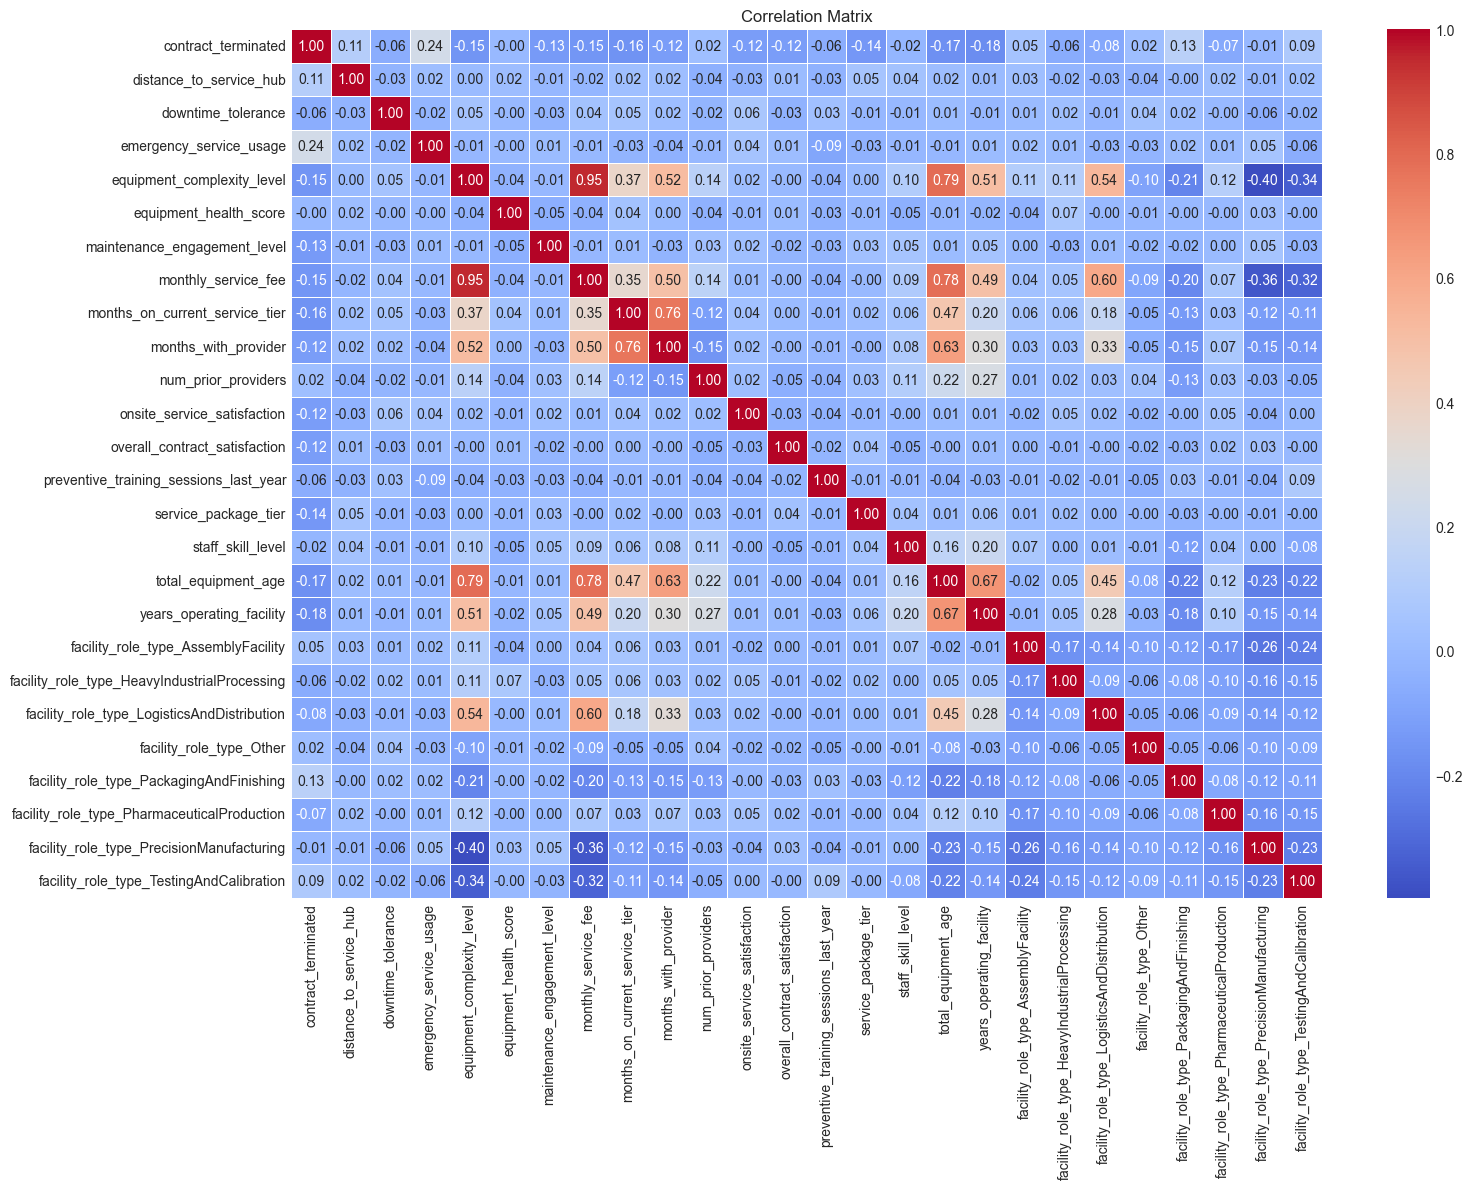

In [78]:
correlation_matrix = data_standardized.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [79]:
print(f" Корелација на излезот со останатите карактеристики- колони:")
data_standardized.corr()["contract_terminated"].sort_values()

 Корелација на излезот со останатите карактеристики- колони:


years_operating_facility                       -0.182573
total_equipment_age                            -0.172910
months_on_current_service_tier                 -0.160150
equipment_complexity_level                     -0.152932
monthly_service_fee                            -0.148384
service_package_tier                           -0.141865
maintenance_engagement_level                   -0.133489
overall_contract_satisfaction                  -0.124466
onsite_service_satisfaction                    -0.123609
months_with_provider                           -0.122712
facility_role_type_LogisticsAndDistribution    -0.079248
facility_role_type_PharmaceuticalProduction    -0.071650
facility_role_type_HeavyIndustrialProcessing   -0.063046
preventive_training_sessions_last_year         -0.055567
downtime_tolerance                             -0.055067
staff_skill_level                              -0.019578
facility_role_type_PrecisionManufacturing      -0.009561
equipment_health_score         

Корелацијата ни укажува кои фактори линеарно влијаат врз раскинувањето на договорите. Најсилниот сигнал за ризик е честата употреба на итни услуги – клиентите кои често имаат проблеми и бараат итна интервенција се оние кај кои најчесто доаѓа до прекин на соработката. Дополнително, оддалеченоста од сервисниот центар и одредени типови објекти (како Packaging and Finishing) исто така носат поголема веројатност за раскинување. 

Од друга страна, стабилноста најмногу се гледа кај долгогодишните клиенти. Колку подолго работи објектот, колку постара е опремата и колку подолго се задржале на исто ниво на услуга, толку е помала веројатноста да го раскинат договорот. Дури и повисоката месечна претплата е поврзана со поголема лојалност.

Има и фактори кои речиси немаат влијание – како состојба на опремата или нивото на вештини на персоналот. Тие не се видно значајни. 

Корелацијата е корисна за првична слика, но не ја опфаќа целата комплексност. За да се откријат такви нелинеарни врски, обично се користат понапредни модели (како decision trees, random forests или neural networks) кои можат да препознаат сложени и криволиниски односи меѓу променливите.



In [80]:
print(f" Корелација на  една карактеристика во однос на друга:")
corr = data_standardized.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

top_corr_pairs = upper.unstack().sort_values(ascending=False)

top_corr_pairs.head(10)

 Корелација на  една карактеристика во однос на друга:


monthly_service_fee                          equipment_complexity_level        0.952588
total_equipment_age                          equipment_complexity_level        0.788227
                                             monthly_service_fee               0.782356
months_with_provider                         months_on_current_service_tier    0.763089
years_operating_facility                     total_equipment_age               0.672063
total_equipment_age                          months_with_provider              0.632269
facility_role_type_LogisticsAndDistribution  monthly_service_fee               0.598501
                                             equipment_complexity_level        0.536979
months_with_provider                         equipment_complexity_level        0.515803
years_operating_facility                     equipment_complexity_level        0.505988
dtype: float64

Овие резултати покажуваат дека многу од карактеристиките се меѓусебно силно поврзани, особено околу комплексноста на опремата, староста на опремата и месечната претплата. Тоа значи дека во модел за предвидување може да постои мултиколинеарност – односно неколку променливи носат речиси истата информација.
За полесно да го исцртаме ова ќе користиме heatmap.

<Axes: >

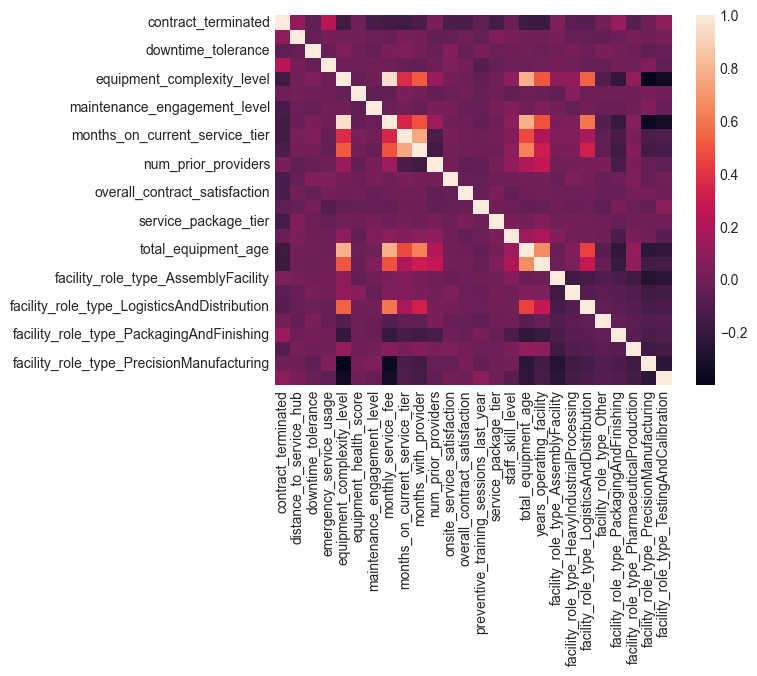

In [81]:
sns.heatmap(data_standardized.corr())

#### За второто најдобро решение во овој дел е направена следната анализа

In [82]:
map_dict = {'No': 0, 'Yes': 1}
data_resenie1_std['emergency_service_usage'] = data_resenie1_std['emergency_service_usage'].map(map_dict)

In [83]:
data_resenie1_std.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,...,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration,service_package_tier_Bronze,service_package_tier_Enterprise,service_package_tier_Gold,service_package_tier_Silver
0,1,0,-0.766864,3,0.0,1,3,2,-0.925511,-1.156707,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,0,-0.766864,3,0.0,2,4,4,0.051729,-0.052808,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,0,-0.149488,3,0.0,2,3,3,-0.308792,-1.156707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,0,-0.149488,3,0.0,3,3,2,1.500306,1.051091,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,1,-0.026013,3,0.0,1,3,2,-0.459830,-0.604758,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Во ова решение се изоставаат оние карактеристики кои имаат најголема меѓусебна корелација.

In [84]:
data_resenie1_before= data_resenie1_std.drop(columns=['monthly_service_fee'])

In [85]:
data_resenie1_before.head()

,ID,contract_terminated,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,months_on_current_service_tier,months_with_provider,...,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration,service_package_tier_Bronze,service_package_tier_Enterprise,service_package_tier_Gold,service_package_tier_Silver
0,1,0,-0.766864,3,0.0,1,3,2,-1.156707,-0.972218,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,0,-0.766864,3,0.0,2,4,4,-0.052808,-0.326548,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,0,-0.149488,3,0.0,2,3,3,-1.156707,-1.133635,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,0,-0.149488,3,0.0,3,3,2,1.051091,0.319123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,1,-0.026013,3,0.0,1,3,2,-0.604758,-0.649383,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<Axes: >

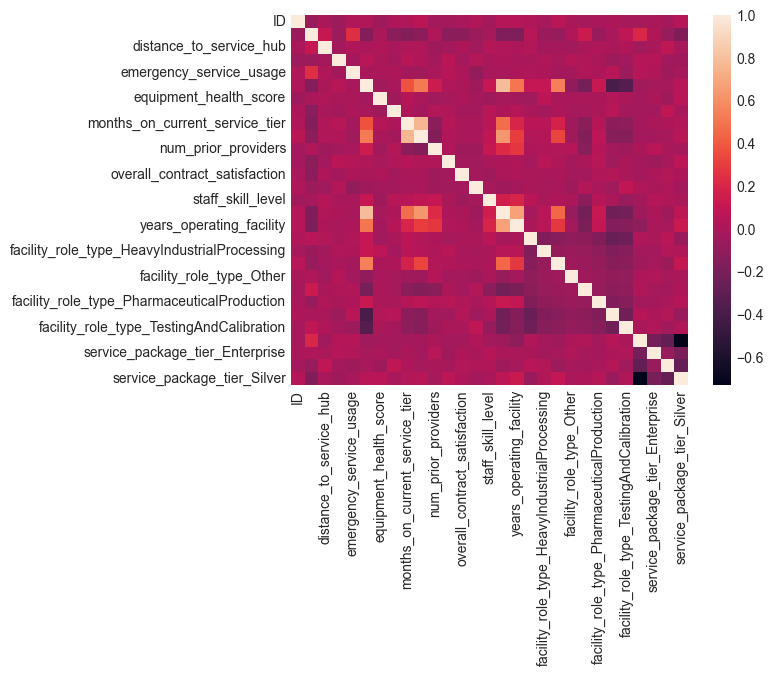

In [86]:
sns.heatmap(data_resenie1_before.corr())

## Примена на техники за балансирање на податочнотомножество

In [87]:
data_balanced=data_standardized.copy()

In [88]:
contract_terminated_count = data_balanced['contract_terminated'].value_counts().sort_index()
print(contract_terminated_count)

contract_terminated
0    913
1    174
Name: count, dtype: int64


Во податочното множество постои јасна нерамнотежа меѓу класите. Огромното мнозинство од записите – 913 случаи – се однесуваат на договори кои не се раскинати, додека само 174 случаи претставуваат раскинати договори. Тоа значи дека околу 84% од податоците се од класа 1, а само 16% се класа 0.

Оваа нерамнотежа има сериозни последици за предвидувањето. Ако се изгради модел без да се земе предвид ваквата распределба, тој ќе има тенденција да ја фаворизира мнозинската класа. На прв поглед може да изгледа дека моделот е „точен“, бидејќи ќе предвидува многу договори како нераскинати и ќе постигнува висока точност. Но во суштина, ќе пропушта голем број случаи каде договорот навистина се раскинува, токму оние кои се најважни за анализа.

Затоа, оваа малцинска класа е критична: целта не е само да се потврди стабилноста на договорите, туку да се препознаат сигналите кои водат кон нивно раскинување. Само со внимателен пристап кон оваа нерамнотежа може да се добие модел што навистина носи вредност.

Во прилог е изворот за оваа анализа и иазбраниот пристап: https://www.kaggle.com/code/chandrimad31/rainfall-prediction-7-popular-models






In [89]:
X = data_balanced.drop("contract_terminated", axis=1)
y = data_balanced["contract_terminated"]

In [90]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [91]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

In [92]:
median_providers = data_balanced['num_prior_providers'].median()
median_providers
data_balanced['num_prior_providers'] = data_balanced['num_prior_providers'].fillna(median_providers)

In [93]:
smote = SMOTE(sampling_strategy={1: 500}, random_state=42)

In [94]:
median_values = X_train.median()

X_train = X_train.fillna(median_values)
X_test = X_test.fillna(median_values)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [95]:
undersample = RandomUnderSampler(sampling_strategy={0: 500}, random_state=42)
X_train_balanced, y_train_balanced = undersample.fit_resample(X_train_smote, y_train_smote)

In [96]:
print(Counter(y_train_balanced))

Counter({0: 500, 1: 500})


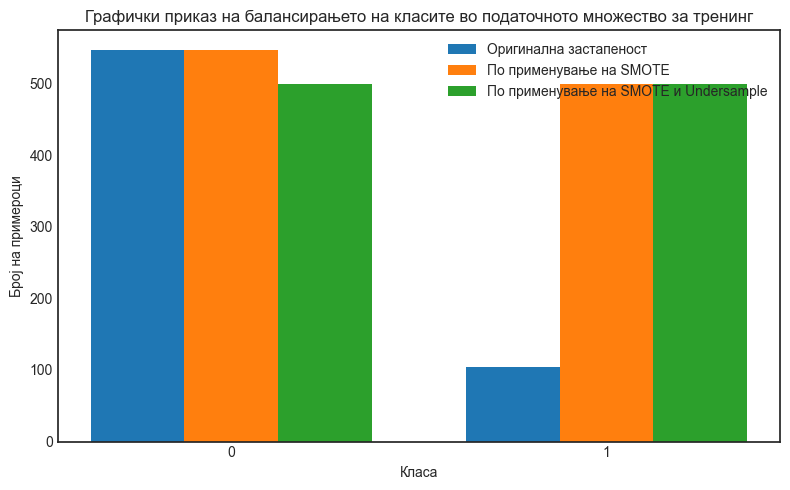

In [97]:
class_counts_before = y_train.value_counts().sort_index()
class_counts_smote = y_train_smote.value_counts().sort_index()
class_counts_under = y_train_balanced.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,5))
width = 0.25
x = range(len(class_counts_before))
ax.bar([i - width for i in x], class_counts_before, width=width, label="Оригинална застапеност")
ax.bar(x, class_counts_smote, width=width, label="По применување на SMOTE")
ax.bar([i + width for i in x], class_counts_under, width=width, label="По применување на SMOTE и Undersample")
ax.set_xlabel("Класа")
ax.set_ylabel("Број на примероци")
ax.set_title("Графички приказ на балансирањето на класите во податочното множество за тренинг")
ax.set_xticks(x)
ax.set_xticklabels(class_counts_before.index)
ax.legend()
plt.tight_layout()
plt.show()


#### За второто најдобро решение

In [98]:
X_2 = data_resenie1_before.drop("contract_terminated", axis=1)
y_2 = data_resenie1_before["contract_terminated"]

In [99]:
X_temp_2, X_test_2, y_temp_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, stratify=y, random_state=42)

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.25, stratify=y_temp, random_state=42)

In [100]:
median_providers = data_resenie1_before['num_prior_providers'].median()
median_providers
data_resenie1_before['num_prior_providers'] = data_resenie1_before['num_prior_providers'].fillna(median_providers)

In [101]:
smote = SMOTE(sampling_strategy={1: 500}, random_state=42)

In [102]:
median_values = X_train_2.median()

X_train_2 = X_train_2.fillna(median_values)
X_test_2 = X_test_2.fillna(median_values)
X_train_smote_2, y_train_smote_2 = smote.fit_resample(X_train_2, y_train_2)

In [103]:
print(Counter(y_train_smote_2))

Counter({0: 547, 1: 500})


Во ова полошо решение не е направено undersampling и податочното множество не е идеално избалансирано.

# Прв круг испробување на модели

Извор во однос на бирање на моделите : https://www.kaggle.com/code/kaanboke/catboost-lightgbm-xgboost-explained-by-shap-

*** забелешка: Домашната почнав да ја изработувам по наведените извори по ќелиите, но секако се служев и со многу други кои ќе бидат рефференцирани на крај. 

## SVM

In [104]:
from sklearn.svm import SVC
svm_model = SVC()
most_frequent = X_train['emergency_service_usage'].mode()[0]  # За категоријска колона
X_val['emergency_service_usage'] = X_val['emergency_service_usage'].fillna(most_frequent)
svm_model.fit(X_train_balanced, y_train_balanced)
y_val_pred_svm = svm_model.predict(X_val)

In [105]:
print("=== SVM Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_svm))

=== SVM Evaluation on Validation Set ===
Accuracy: 0.7477064220183486
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       183
           1       0.34      0.60      0.43        35

    accuracy                           0.75       218
   macro avg       0.62      0.69      0.64       218
weighted avg       0.82      0.75      0.77       218



## Random Forest

In [106]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,       
    max_depth=20,          
    min_samples_split=5,  
    min_samples_leaf=2,    
    max_features="sqrt",   
    bootstrap=True,        
    random_state=42,
    n_jobs=-1              
)
rf_model.fit(X_train_balanced, y_train_balanced)
y_val_pred_rf = rf_model.predict(X_val)

In [107]:
print("=== RF Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print(confusion_matrix(y_val, y_val_pred_rf))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf))

=== RF Evaluation on Validation Set ===
Accuracy: 0.8302752293577982
[[167  16]
 [ 21  14]]
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       183
           1       0.47      0.40      0.43        35

    accuracy                           0.83       218
   macro avg       0.68      0.66      0.67       218
weighted avg       0.82      0.83      0.82       218



##  XGBoost

In [108]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,          
    learning_rate=0.05,        
    max_depth=6,               
    subsample=0.8,             
    colsample_bytree=0.8,      
    gamma=0.1,                 
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    min_child_weight=3,        
    random_state=42,
    verbosity=0,
    tree_method="hist"         
)

xgb_model.fit(X_train_balanced, y_train_balanced)
y_val_pred_xgb = xgb_model.predict(X_val)


In [109]:
print("=== XGBoost Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Classification Report:")
print(classification_report(y_val, y_val_pred_xgb))

=== XGBoost Evaluation on Validation Set ===
Accuracy: 0.8211009174311926
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       183
           1       0.44      0.46      0.45        35

    accuracy                           0.82       218
   macro avg       0.67      0.67      0.67       218
weighted avg       0.82      0.82      0.82       218



## CATBoost

In [110]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(
    iterations=1500,           
    learning_rate=0.02,        
    depth=10,                 
    l2_leaf_reg=6,             
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 6],      
    random_seed=42,
    subsample=0.8,             
    colsample_bylevel=0.8,     
    border_count=128,         
    verbose=200
)

model_cat.fit(X_train_balanced, y_train_balanced)
y_val_pred_catboost = model_cat.predict(X_val)


0:	learn: 0.9441868	total: 121ms	remaining: 3m 1s
200:	learn: 0.9857072	total: 4s	remaining: 25.9s
400:	learn: 0.9971747	total: 8.25s	remaining: 22.6s
600:	learn: 0.9995002	total: 12.2s	remaining: 18.2s
800:	learn: 1.0000000	total: 16.4s	remaining: 14.3s
1000:	learn: 1.0000000	total: 20.4s	remaining: 10.2s
1200:	learn: 1.0000000	total: 24.8s	remaining: 6.17s
1400:	learn: 1.0000000	total: 29.3s	remaining: 2.07s
1499:	learn: 1.0000000	total: 31.5s	remaining: 0us


In [111]:
print("=== CAT Evaluation on Validation Set ===")
print("F1:", f1_score(y_val, y_val_pred_catboost))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_catboost))

=== CAT Evaluation on Validation Set ===
F1: 0.5217391304347826
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       183
           1       0.42      0.69      0.52        35

    accuracy                           0.80       218
   macro avg       0.68      0.75      0.70       218
weighted avg       0.85      0.80      0.82       218



Параметрите на некои од моделите се ископирани од веќе постоечки кодови, кои решаваат сличен или идентичен проблем како нашата задача. 

## Споредување на различните модели

In [112]:
model_predictions = {
    'Random Forest': y_val_pred_rf,
    'XGBoost': y_val_pred_xgb,
    'CatBoost': y_val_pred_catboost,
}

results = {
    'Model': [],
    'Accuracy': [],
    'F1 Macro Avg': [],
    'F1 Weighted Avg': [],
    'Precision': [],
    'Recall': []
}

for model_name, y_pred in model_predictions.items():
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy_score(y_val, y_pred))
    results['F1 Macro Avg'].append(f1_score(y_val, y_pred, average='macro'))
    results['F1 Weighted Avg'].append(f1_score(y_val, y_pred, average='weighted'))
    results['Precision'].append(precision_score(y_val, y_pred, average='weighted'))
    results['Recall'].append(recall_score(y_val, y_pred, average='weighted'))

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='F1 Macro Avg', ascending=False)


In [113]:
comparison_df

,Model,Accuracy,F1 Macro Avg,F1 Weighted Avg,Precision,Recall
2,CatBoost,0.798165,0.696916,0.815844,0.849696,0.798165
1,XGBoost,0.821101,0.671927,0.822116,0.823170,0.821101
0,Random Forest,0.830275,0.665519,0.824891,0.820605,0.830275


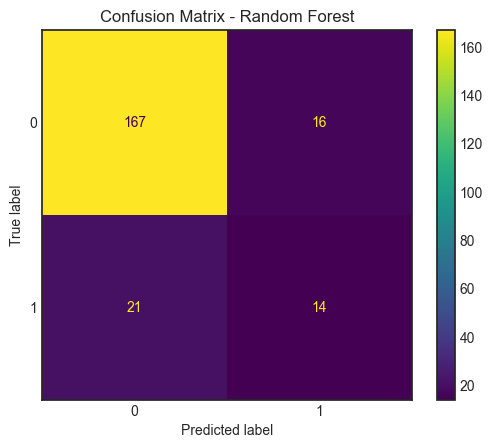

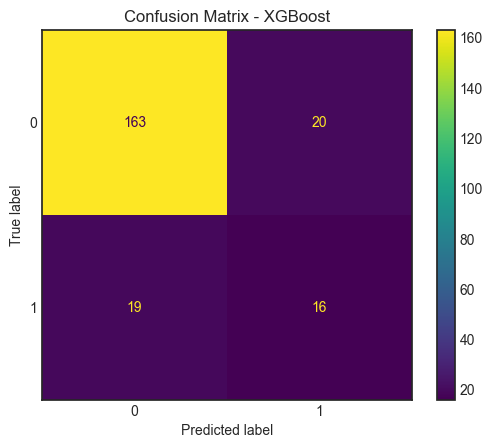

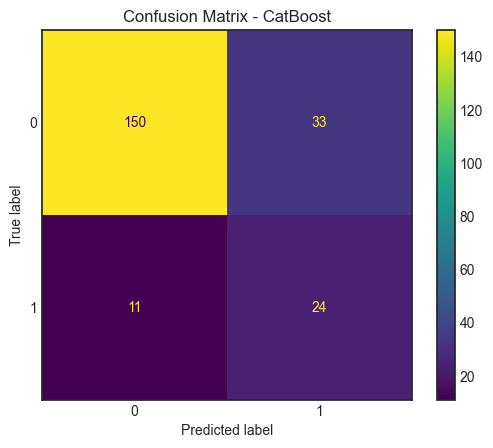

In [114]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_catboost)
plt.title("Confusion Matrix - CatBoost")
plt.show()

# FEATURE SELECTION- Бирање на најсоодветни карактеристики

Извор за овој дел: 
- https://www.geeksforgeeks.org/machine-learning/feature-selection-using-random-forest-classifier/

- https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html     
- https://machinelearningmastery.com/calculate-feature-importance-with-python/
- https://builtin.com/data-science/feature-importance



## За Random Forest

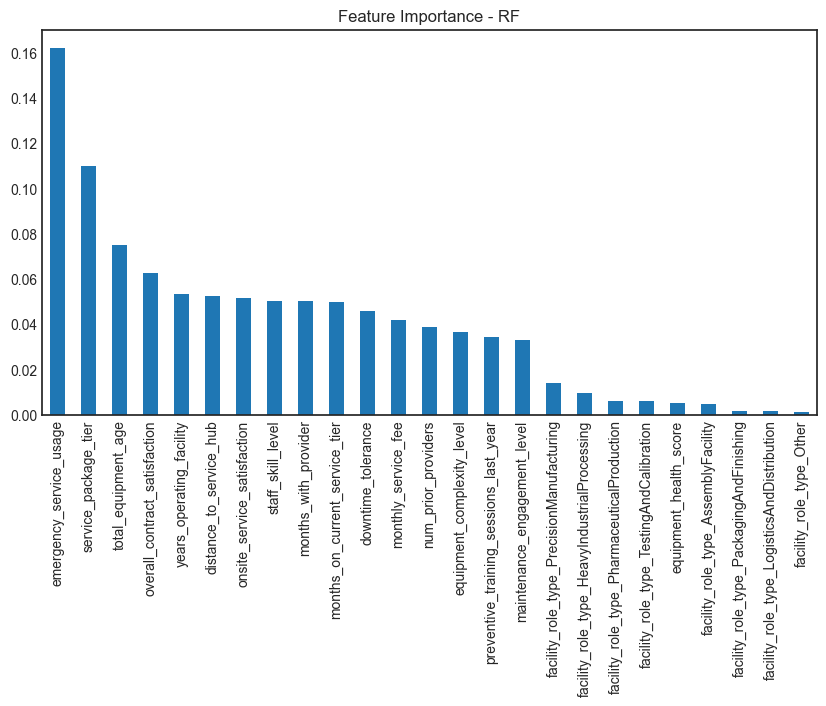

In [115]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title='Feature Importance - RF')
plt.show()

In [116]:
full_feature_list = X_train_balanced.columns.tolist()

removal_results_full = []
for feature in full_feature_list:
    test_features = [f for f in full_feature_list if f != feature]
    X_train_test = X_train_balanced[test_features]
    X_val_test = X_val[test_features]
    model = clone(rf_model)   
    model.fit(X_train_test, y_train_balanced)
    y_val_pred = model.predict(X_val_test)
    f1 = f1_score(y_val, y_val_pred, average='macro')
    removal_results_full.append({
        'Removed Feature': feature,
        'F1': f1
    })

removal_results_df = pd.DataFrame(removal_results_full)
removal_results_df = removal_results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)
removal_results_df

,Removed Feature,F1
0,months_with_provider,0.726651
1,staff_skill_level,0.714333
2,months_on_current_service_tier,0.696478
3,preventive_training_sessions_last_year,0.696478
4,equipment_health_score,0.696478
5,monthly_service_fee,0.691380
6,num_prior_providers,0.691380
7,equipment_complexity_level,0.688676
8,total_equipment_age,0.686381
9,facility_role_type_PharmaceuticalProduction,0.683599


In [117]:
worst_features = [
    "months_with_provider",
    "staff_skill_level",
    "months_on_current_service_tier",
    "preventive_training_sessions_last_year",
    "equipment_health_score",
    "monthly_service_fee",
    "num_prior_providers"
]


In [118]:
best_features = [
    "equipment_complexity_level",
    "total_equipment_age",
    "facility_role_type_PharmaceuticalProduction",
    "facility_role_type_HeavyIndustrialProcessing",
    "facility_role_type_AssemblyFacility",
    "facility_role_type_Other",
    "facility_role_type_TestingAndCalibration",
    "facility_role_type_PrecisionManufacturing",
    "facility_role_type_LogisticsAndDistribution",
    "years_operating_facility",
    "maintenance_engagement_level",
    "facility_role_type_PackagingAndFinishing",
    "service_package_tier",
    "distance_to_service_hub",
    "downtime_tolerance",
    "overall_contract_satisfaction",
    "onsite_service_satisfaction",
    "emergency_service_usage"
]


#### Повторно требирање со новите подобрени карактеристики

In [119]:
X_train_reduced = X_train_balanced[best_features]
X_val_reduced = X_val[best_features]

In [120]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_reduced, y_train_balanced)
y_val_pred_rf_top = rf_model.predict(X_val_reduced)

In [121]:
print("=== RF Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_top))
print("__________________________")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_top))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf_top))

=== RF Evaluation on Validation Set ===
Accuracy: 0.8394495412844036
__________________________
Confusion Matrix:
[[165  18]
 [ 17  18]]
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       183
           1       0.50      0.51      0.51        35

    accuracy                           0.84       218
   macro avg       0.70      0.71      0.71       218
weighted avg       0.84      0.84      0.84       218



In [122]:
print("=== RF Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print(confusion_matrix(y_val, y_val_pred_rf))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf))

=== RF Evaluation on Validation Set ===
Accuracy: 0.8302752293577982
[[167  16]
 [ 21  14]]
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       183
           1       0.47      0.40      0.43        35

    accuracy                           0.83       218
   macro avg       0.68      0.66      0.67       218
weighted avg       0.82      0.83      0.82       218



Се забележува големо подобрување со избирање на најдобрите карактеристики за тренинг. Освен што е зголемен делот за f1 во однос на класата на единици, зголемен е и recall. Recall се зголемува од 40 на 51, што ни е најважно во моделот. Дури и да мислиме дека некоја 0 е 1 и лажно да се сомневаме дека клиентот ќе не напушти, е подобро отколку да се излажеме дека некој клиент ќе остане, а тој да си замине. 

## За XGB

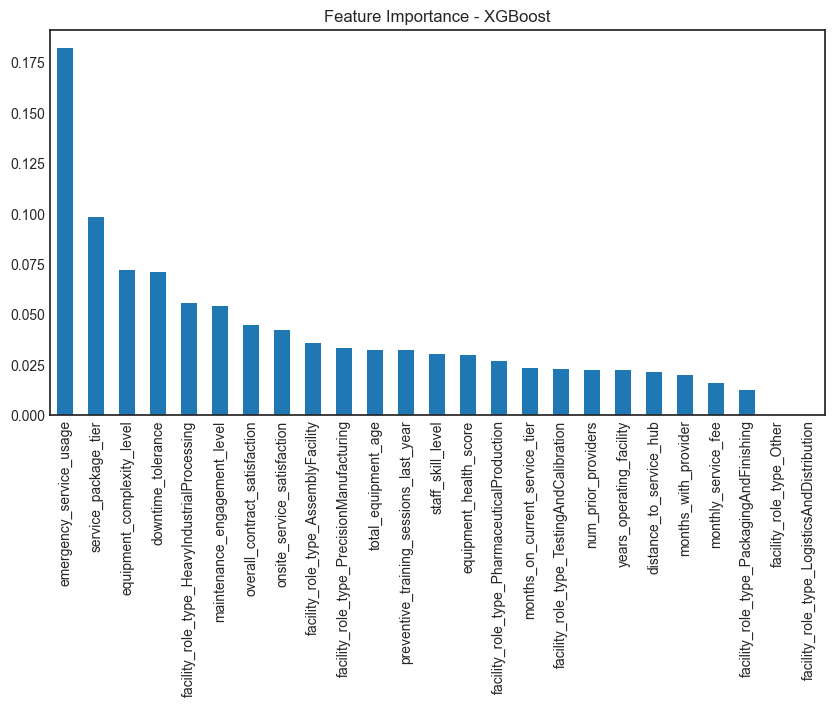

In [123]:
importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title='Feature Importance - XGBoost')
plt.show()

In [124]:
full_feature_list = X_train_balanced.columns.tolist()

removal_results_full = []

for feature in full_feature_list:
    test_features = [f for f in full_feature_list if f != feature]

    X_train_test = X_train_balanced[test_features]
    X_val_test = X_val[test_features]

    model = clone(xgb_model)   
    model.fit(X_train_test, y_train_balanced)
    y_val_pred = model.predict(X_val_test)

    f1 = f1_score(y_val, y_val_pred, average='macro')

    removal_results_full.append({
        'Removed Feature': feature,
        'F1': f1
    })

removal_results_df = pd.DataFrame(removal_results_full)
removal_results_df = removal_results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)
removal_results_df

,Removed Feature,F1
0,staff_skill_level,0.733822
1,total_equipment_age,0.705576
2,facility_role_type_PharmaceuticalProduction,0.705576
3,facility_role_type_AssemblyFacility,0.700549
4,months_with_provider,0.700549
5,facility_role_type_PackagingAndFinishing,0.698693
6,facility_role_type_TestingAndCalibration,0.698693
7,facility_role_type_HeavyIndustrialProcessing,0.698693
8,months_on_current_service_tier,0.695611
9,years_operating_facility,0.695611


In [ ]:
worst_features = [
    "staff_skill_level",
    "total_equipment_age",
    "facility_role_type_PharmaceuticalProduction",
    "facility_role_type_AssemblyFacility",
    "months_with_provider",
    "facility_role_type_PackagingAndFinishing",
    "facility_role_type_TestingAndCalibration"
]


In [ ]:
best_features = [
    "facility_role_type_HeavyIndustrialProcessing",
    "months_on_current_service_tier",
    "years_operating_facility",
    "facility_role_type_Other",
    "equipment_health_score",
    "facility_role_type_LogisticsAndDistribution",
    "preventive_training_sessions_last_year",
    "equipment_complexity_level",
    "downtime_tolerance",
    "monthly_service_fee",
    "num_prior_providers",
    "maintenance_engagement_level",
    "onsite_service_satisfaction",
    "distance_to_service_hub",
    "overall_contract_satisfaction",
    "facility_role_type_PrecisionManufacturing",
    "service_package_tier",
    "emergency_service_usage"
]


#### Повторно требирање со новите подобрени карактеристики

In [146]:
X_train_reduced_xgb= X_train_balanced[best_features]
X_val_reduced = X_val[best_features]

In [148]:
X_train_XGB=X_train_reduced_xgb.copy()

In [147]:
rf_model = XGBClassifier(random_state=42)
rf_model.fit(X_train_reduced_xgb, y_train_balanced)
y_val_pred_xgb_top = rf_model.predict(X_val_reduced)

In [129]:
print("=== XGB Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb_top))
print("__________________________")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_top))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_xgb_top))

=== XGB Evaluation on Validation Set ===
Accuracy: 0.8211009174311926
__________________________
Confusion Matrix:
[[160  23]
 [ 16  19]]
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       183
           1       0.45      0.54      0.49        35

    accuracy                           0.82       218
   macro avg       0.68      0.71      0.69       218
weighted avg       0.84      0.82      0.83       218



In [130]:
print("=== XGBoost Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Classification Report:")
print(classification_report(y_val, y_val_pred_xgb))

=== XGBoost Evaluation on Validation Set ===
Accuracy: 0.8211009174311926
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       183
           1       0.44      0.46      0.45        35

    accuracy                           0.82       218
   macro avg       0.67      0.67      0.67       218
weighted avg       0.82      0.82      0.82       218



Се забележува подобрување на f1 score и на recall истовремено, користејќи ги само best features во повторното тренирање на моделот.

## За CATBoost

In [131]:
full_feature_list = X_train_balanced.columns.tolist()

removal_results_full = []

for feature in full_feature_list:
    test_features = [f for f in full_feature_list if f != feature]

    X_train_test = X_train_balanced[test_features]
    X_val_test = X_val[test_features]

    model = clone(model_cat)   
    model.fit(X_train_test, y_train_balanced)
    y_val_pred = model.predict(X_val_test)

    f1 = f1_score(y_val, y_val_pred, average='macro')

    removal_results_full.append({
        'Removed Feature': feature,
        'F1': f1
    })

removal_results_df = pd.DataFrame(removal_results_full)
removal_results_df = removal_results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)
removal_results_df


0:	learn: 0.9462020	total: 54ms	remaining: 1m 20s
200:	learn: 0.9845750	total: 3.47s	remaining: 22.4s
400:	learn: 0.9956854	total: 8.79s	remaining: 24.1s
600:	learn: 0.9991674	total: 13.4s	remaining: 20s
800:	learn: 0.9998334	total: 17.8s	remaining: 15.5s
1000:	learn: 1.0000000	total: 21.8s	remaining: 10.9s
1200:	learn: 1.0000000	total: 25.3s	remaining: 6.31s
1400:	learn: 1.0000000	total: 29s	remaining: 2.05s
1499:	learn: 1.0000000	total: 30.7s	remaining: 0us
0:	learn: 0.9462020	total: 19.8ms	remaining: 29.6s
200:	learn: 0.9828010	total: 5.26s	remaining: 34s
400:	learn: 0.9961813	total: 9.15s	remaining: 25.1s
600:	learn: 0.9991674	total: 13s	remaining: 19.4s
800:	learn: 0.9996668	total: 17.1s	remaining: 14.9s
1000:	learn: 1.0000000	total: 21.1s	remaining: 10.5s
1200:	learn: 1.0000000	total: 25s	remaining: 6.21s
1400:	learn: 1.0000000	total: 29.7s	remaining: 2.1s
1499:	learn: 1.0000000	total: 31.6s	remaining: 0us
0:	learn: 0.9431310	total: 16.5ms	remaining: 24.7s
200:	learn: 0.9802320	t

,Removed Feature,F1
0,total_equipment_age,0.701417
1,num_prior_providers,0.697175
2,downtime_tolerance,0.697175
3,facility_role_type_LogisticsAndDistribution,0.696916
4,staff_skill_level,0.692467
5,facility_role_type_HeavyIndustrialProcessing,0.691972
6,facility_role_type_PharmaceuticalProduction,0.691269
7,facility_role_type_PackagingAndFinishing,0.687530
8,facility_role_type_PrecisionManufacturing,0.684096
9,facility_role_type_TestingAndCalibration,0.683140


In [132]:
worst_features_cat = [
    "total_equipment_age",
    "num_prior_providers",
    "downtime_tolerance",
    "facility_role_type_LogisticsAndDistribution",
    "staff_skill_level",
    "facility_role_type_HeavyIndustrialProcessing",
    "facility_role_type_PharmaceuticalProduction"
]


In [133]:
best_features_cat = [
    "facility_role_type_PackagingAndFinishing",
    "facility_role_type_PrecisionManufacturing",
    "facility_role_type_TestingAndCalibration",
    "preventive_training_sessions_last_year",
    "facility_role_type_AssemblyFacility",
    "years_operating_facility",
    "months_with_provider",
    "monthly_service_fee",
    "equipment_complexity_level",
    "months_on_current_service_tier",
    "onsite_service_satisfaction",
    "equipment_health_score",
    "maintenance_engagement_level",
    "facility_role_type_Other",
    "service_package_tier",
    "overall_contract_satisfaction",
    "emergency_service_usage",
    "distance_to_service_hub"
]


#### Повторно требирање со новите подобрени карактеристики

In [134]:
X_train_reduced_cat = X_train_balanced[best_features_cat]
X_val_reduced_cat = X_val[best_features_cat]

In [136]:
rf_model = CatBoostClassifier(random_state=42)
rf_model.fit(X_train_reduced_cat, y_train_balanced)
X_val_reduced = X_val_reduced.reindex(columns=X_train_reduced_cat.columns, fill_value=0)
y_val_pred_cat_top = rf_model.predict(X_val_reduced)

Learning rate set to 0.010302
0:	learn: 0.6850755	total: 7.41ms	remaining: 7.4s
1:	learn: 0.6771985	total: 14.2ms	remaining: 7.07s
2:	learn: 0.6694142	total: 20.3ms	remaining: 6.74s
3:	learn: 0.6620553	total: 27.8ms	remaining: 6.93s
4:	learn: 0.6564182	total: 33.7ms	remaining: 6.7s
5:	learn: 0.6505204	total: 40.8ms	remaining: 6.76s
6:	learn: 0.6436437	total: 46.8ms	remaining: 6.64s
7:	learn: 0.6380470	total: 52.4ms	remaining: 6.5s
8:	learn: 0.6310991	total: 59.3ms	remaining: 6.53s
9:	learn: 0.6250912	total: 179ms	remaining: 17.7s
10:	learn: 0.6196793	total: 184ms	remaining: 16.6s
11:	learn: 0.6139631	total: 191ms	remaining: 15.7s
12:	learn: 0.6087615	total: 197ms	remaining: 14.9s
13:	learn: 0.6031489	total: 203ms	remaining: 14.3s
14:	learn: 0.5969886	total: 280ms	remaining: 18.4s
15:	learn: 0.5912080	total: 289ms	remaining: 17.8s
16:	learn: 0.5848430	total: 297ms	remaining: 17.2s
17:	learn: 0.5793430	total: 305ms	remaining: 16.6s
18:	learn: 0.5743965	total: 310ms	remaining: 16s
19:	lea

In [137]:
print("=== CATBoost Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_cat_top))
print("Classification Report:")
print(classification_report(y_val, y_val_pred_cat_top))

=== CATBoost Evaluation on Validation Set ===
Accuracy: 0.8256880733944955
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       183
           1       0.47      0.74      0.58        35

    accuracy                           0.83       218
   macro avg       0.71      0.79      0.73       218
weighted avg       0.87      0.83      0.84       218



Ова всушност претставува првиот прикачен модел. Public score: 0.37288; Private score: 0.54054

In [138]:
print("=== CAT Evaluation on Validation Set ===")
print("F1:", f1_score(y_val, y_val_pred_catboost))
print("__________________________")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_catboost))

=== CAT Evaluation on Validation Set ===
F1: 0.5217391304347826
__________________________
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       183
           1       0.42      0.69      0.52        35

    accuracy                           0.80       218
   macro avg       0.68      0.75      0.70       218
weighted avg       0.85      0.80      0.82       218



Подобрен е f1, но опадната е recall, зголемена precision.

# Пронаоѓање на најдобри хипер- параметри за XGB и CATBoost

Хипер-параметрите ќе ги изнајдеме со randomized search и gread search, бидејќи тие беа најкористени, при истражувањето. Ова го правиме со цел да го зголемиме f1, особено на малцинската класа 1.Ова со малцинската класа има логика само ако суштински го разгледаме проблемот. Иако додадовме синтетички вредмости, повеќе сакаме да се сомневаме дека некој клиент ќе си замине, а да не го направи тоа, отколку обратната ситуација.
Слично на ова е класифицирање на тумор (секогаш ја предвидуваме полошата варијанта).

## За XGB

### Grid search

In [ ]:
xgb = XGBClassifier()

param_grid = {
    'max_depth': [4, 7, 10],
    'learning_rate': [0.02, 0.05, 0.1],
    'n_estimators': [100, 150, 250],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9]
}

grid_search_RF = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

grid_search_RF.fit(X_train, y_train)

print("Best parameters found: ", grid_search_RF.best_params_)

best_model = grid_search_RF.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters found:  {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 250, 'subsample': 0.6}
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       183
           1       0.69      0.31      0.43        35

    accuracy                           0.87       218
   macro avg       0.78      0.64      0.68       218
weighted avg       0.85      0.87      0.85       218



###  Randomized search

In [ ]:
xgb = XGBClassifier()
param_distributions = {
    'max_depth': np.random.randint(3, 8, size=10),  
    'learning_rate': np.random.uniform(0.01, 0.1, size=10),  
    'n_estimators': [100, 150, 200, 250],  
    'subsample': np.random.uniform(0.8, 1.0, size=10), 
    'colsample_bytree': np.random.uniform(0.8, 1.0, size=10),  
    'gamma': np.random.uniform(0, 0.3, size=10),  
    'min_child_weight': np.random.randint(2, 8, size=10)  
}

random_search_rf = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_distributions, 
    n_iter=50,  
    cv=5,        
    n_jobs=-1,   
    verbose=1,   
    random_state=42,  
    scoring='f1'  
)


random_search_rf.fit(X_train_reduced_xgb, y_train)
print("Best parameters found: ", random_search_rf.best_params_)

best_model = random_search_rf.best_estimator_
y_pred = best_model.predict(X_test_reduced)
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'subsample': np.float64(0.8540015856509364), 'n_estimators': 200, 'min_child_weight': np.int32(6), 'max_depth': np.int32(4), 'learning_rate': np.float64(0.07718603495579744), 'gamma': np.float64(0.07319789931740289), 'colsample_bytree': np.float64(0.833928228050609)}
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       183
           1       0.69      0.31      0.43        35

    accuracy                           0.87       218
   macro avg       0.78      0.64      0.68       218
weighted avg       0.85      0.87      0.85       218



## За CATBoost

### Gread Srarch

## 

In [166]:
param_grid = {
    'iterations': [100, 200],
    'depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'bagging_temperature': [0, 0.5, 1],
    'rsm': [0.8, 1]  
}

grid_search = GridSearchCV(
    estimator=CatBoostClassifier(
        verbose=0,       
        random_state=42,
        task_type='CPU',  
        eval_metric='F1'
    ),
    param_grid=param_grid,
    scoring='f1_macro',  
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_reduced_cat, y_train_balanced)
best_params = grid_search.best_params_
print("Best parameters from GridSearch:\n", best_params)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters from GridSearch:
 {'bagging_temperature': 0, 'depth': 7, 'iterations': 200, 'learning_rate': 0.1, 'rsm': 0.8}


In [169]:
best_catmodel_model_grid = grid_search.best_estimator_
X_train_reduced_cat, y_train = X_train_reduced_cat.align(y_train, join='inner', axis=0)
grid_search.fit(X_train_reduced_cat, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostClassifier object at 0x000001EEFC247800>,
             n_jobs=-1,
             param_grid={'bagging_temperature': [0, 0.5, 1], 'depth': [3, 5, 7],
                         'iterations': [100, 200], 'learning_rate': [0.05, 0.1],
                         'rsm': [0.8, 1]},
             scoring='f1_macro', verbose=1)

In [ ]:

y_val_pred = best_catmodel_model_grid.predict(X_val_reduced)


In [173]:
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88       183
           1       0.44      0.74      0.55        35

    accuracy                           0.81       218
   macro avg       0.69      0.78      0.72       218
weighted avg       0.86      0.81      0.83       218



In [ ]:
print("=== CATBoost Evaluation on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_cat_top))
print("Classification Report:")
print(classification_report(y_val, y_val_pred_cat_top))

=== CATBoost Evaluation on Validation Set ===
Accuracy: 0.8394495412844036
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       183
           1       0.50      0.66      0.57        35

    accuracy                           0.84       218
   macro avg       0.72      0.77      0.73       218
weighted avg       0.86      0.84      0.85       218



Ова е најдоброто прикачено решение,кое во првото извршување беше видно подобро. Даваше и подобар f1, за една единица во однос на претходното само со избрани best features. 
Подобрувањето на Recall и таму беше забележителна.

# Трето „најлошо“ решение

Во однос на третото решение, разликата е во обработката на податоци, како што е прикажано и погоре, без features engeneering, но со gird search за моделот CATBoost. 
Основната грешка таму е користење само на функцијата SMOTE, без undersampling, со што податочното множество не е идеално избалансирано. Дополнително, мора да се забележи и тоа што за сите ненумерички податоци се користеше OneHotEncoding во тоа решение, при што немаше редослед подобро- повисок број, како што тоа е направено во првите 2 решенија. 
За наведеното решение како најлошо, ги добив следниве резултати: Public Score: 0.36144; Private Score:  0.49180

# Вчитување и обработка на тест множеството

In [151]:
test_data=pd.read_csv('IndustrialMaintenanceClientRetention_Testing.csv')

In [152]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,363.0,182.000000,104.933312,1.0,91.5,182.0,272.5,363.0
distance_to_service_hub,363.0,9.082645,8.092613,1.0,2.0,7.0,13.0,29.0
downtime_tolerance,363.0,2.768595,0.729342,1.0,2.0,3.0,3.0,4.0
equipment_complexity_level,363.0,2.022039,1.066600,1.0,1.0,2.0,3.0,5.0
equipment_health_score,363.0,3.134986,0.342181,3.0,3.0,3.0,3.0,4.0
maintenance_engagement_level,363.0,2.741047,0.727628,1.0,2.0,3.0,3.0,4.0
monthly_service_fee,363.0,6214.371901,4481.525948,1052.0,2922.5,4663.0,7497.0,19999.0
months_on_current_service_tier,363.0,4.347107,3.623993,0.0,2.0,3.0,7.0,18.0
months_with_provider,363.0,27555.110193,524863.465283,0.0,3.0,5.0,9.0,9999999.0
num_prior_providers,363.0,2.630854,2.514343,0.0,1.0,1.0,4.0,9.0


In [153]:
missing_by_column = test_data.isnull().sum()
print("Број на NaN вредности по колона:\n", missing_by_column)

Број на NaN вредности по колона:
 ID                                        0
distance_to_service_hub                   0
downtime_tolerance                        0
emergency_service_usage                   0
equipment_complexity_level                0
equipment_health_score                    0
facility_role_type                        0
maintenance_engagement_level              0
monthly_service_fee                       0
months_on_current_service_tier            0
months_with_provider                      0
num_prior_providers                       0
onsite_service_satisfaction               0
overall_contract_satisfaction             0
preventive_training_sessions_last_year    0
service_package_tier                      0
staff_skill_level                         0
total_equipment_age                       0
years_operating_facility                  0
dtype: int64


In [154]:
test_data_encoded=test_data.copy()
map_dict = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Enterprise': 3}
test_data_encoded['service_package_tier'] = test_data_encoded['service_package_tier'].map(map_dict)

In [155]:
map_dict = {'No': 0, 'Yes': 1}
test_data_encoded['emergency_service_usage'] = test_data_encoded['emergency_service_usage'].map(map_dict)

In [156]:
test_data_encoded = pd.get_dummies(test_data_encoded, columns=['facility_role_type'], drop_first=True)

In [157]:
bool_cols =test_data_encoded.select_dtypes(include='bool').columns
test_data_encoded[bool_cols] = test_data_encoded[bool_cols].astype(int)

In [158]:
prefix = 'facility_role_type'
print(f" Колони кои започнуваат со '{prefix}':\n")
facility_role_cols = test_data_encoded.filter(like=prefix).columns
for col in facility_role_cols:
    print(col)

print(f"\nВкупно пронајдени колони: {len(facility_role_cols)}")

 Колони кои започнуваат со 'facility_role_type':

facility_role_type_AssemblyFacility
facility_role_type_HeavyIndustrialProcessing
facility_role_type_LogisticsAndDistribution
facility_role_type_Other
facility_role_type_PackagingAndFinishing
facility_role_type_PharmaceuticalProduction
facility_role_type_PrecisionManufacturing
facility_role_type_TestingAndCalibration

Вкупно пронајдени колони: 8


In [159]:
numeric_cols = test_data_encoded.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['ID',
 'distance_to_service_hub',
 'downtime_tolerance',
 'emergency_service_usage',
 'equipment_complexity_level',
 'equipment_health_score',
 'maintenance_engagement_level',
 'monthly_service_fee',
 'months_on_current_service_tier',
 'months_with_provider',
 'num_prior_providers',
 'onsite_service_satisfaction',
 'overall_contract_satisfaction',
 'preventive_training_sessions_last_year',
 'service_package_tier',
 'staff_skill_level',
 'total_equipment_age',
 'years_operating_facility',
 'facility_role_type_AssemblyFacility',
 'facility_role_type_HeavyIndustrialProcessing',
 'facility_role_type_LogisticsAndDistribution',
 'facility_role_type_Other',
 'facility_role_type_PackagingAndFinishing',
 'facility_role_type_PharmaceuticalProduction',
 'facility_role_type_PrecisionManufacturing',
 'facility_role_type_TestingAndCalibration']

In [161]:
scaler = StandardScaler()
test_data_encoded[cols_to_scale] = scaler.fit_transform(test_data_encoded[cols_to_scale])

In [162]:
test_data_encoded.head()

,ID,distance_to_service_hub,downtime_tolerance,emergency_service_usage,equipment_complexity_level,equipment_health_score,maintenance_engagement_level,monthly_service_fee,months_on_current_service_tier,months_with_provider,...,total_equipment_age,years_operating_facility,facility_role_type_AssemblyFacility,facility_role_type_HeavyIndustrialProcessing,facility_role_type_LogisticsAndDistribution,facility_role_type_Other,facility_role_type_PackagingAndFinishing,facility_role_type_PharmaceuticalProduction,facility_role_type_PrecisionManufacturing,facility_role_type_TestingAndCalibration
0,1,-0.876407,3,0,1,3,2,-0.278497,0.733046,-0.052555,...,-0.126104,-0.692987,0,0,0,0,0,0,1,0
1,2,2.464574,4,0,1,3,3,-0.515574,-0.648552,-0.052561,...,-0.633317,-1.339102,0,0,0,0,0,0,0,1
2,3,-1.000147,4,0,1,4,3,-0.927385,-0.372232,-0.052563,...,-0.633317,-0.692987,0,0,0,1,0,0,0,0
3,4,2.093354,3,0,2,3,2,0.396981,-0.648552,-0.052568,...,-0.633317,1.029987,1,0,0,0,0,0,0,0
4,5,-0.628927,3,1,2,3,2,-0.086333,0.733046,-0.052557,...,-0.379711,-1.123730,1,0,0,0,0,0,0,0


In [163]:
X_test_final=test_data_encoded

In [174]:
y_test_final = best_catmodel_model_grid.predict(X_test_final)

In [ ]:
df_out = pd.DataFrame({
    'ID': X_test_final['ID'], 
    'contract_terminated':y_test_final
})

df_out.to_csv('submission_data2.csv', index=False)

# Референци

- [1] Bahiru, T.K., Singh, D.K. and Tessfaw, E.A., 2018, April. Comparative study on data mining classification algorithms for predicting road traffic accident severity. In 2018 Second International Conference on Inventive Communication and Computational Technologies (ICICCT) (pp. 1655-1660). IEEE. (Линк за пристап: https://www.aasmr.org/jsms/Vol14/No.12/Vol.14.No.12.09.pdf)

- [2] Mena, G., Coussement, K., De Bock, K.W., De Caigny, A. and Lessmann, S., 2024. Exploiting time-varying RFM measures for customer churn prediction with deep neural networks. Annals of Operations Research, 339(1), pp.765-787. (Линк за пристап: https://hal.science/hal-04680677/document)

- [3] Kabbar, E. and Herath, R., 2025. Customer churn prediction to enhance customer retention strategies in the banking industry: A study using seven machine learning algorithms. (Линк за пристап: https://ibimapublishing.com/articles/JSSD/2025/786386/786386.pdf)

- [4] Линк: https://builtin.com/data-science/feature-importance

- [5] Линк: https://machinelearningmastery.com/calculate-feature-importance-with-python/ 

- [6] Линк: https://www.kaggle.com/code/discdiver/guide-to-scaling-and-standardizing

- [7] Линк: https://www.kaggle.com/code/mrisdal/exploring-survival-on-the-titanic

- [8] Линк: https://www.kaggle.com/learn/data-cleaning

- [9] Линк: https://www.kaggle.com/code/hopesb/diabetes-prediction-challenge

- [10] Линк: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

- [11] Линк: https://github.com/ohmthanap/Telecom-Customer-Churn-Predictions/blob/main/Telco%20Customer%20Churn%20Prediction.ipynb

- [12] Линк: https://www.kaggle.com/code/mnassrib/customer-churn-prediction-telecom-churn-dataset

- [13] Линк: https://www.geeksforgeeks.org/data-analysis/exploratory-data-analysis-in-python/

- [14] Линк: https://www.kaggle.com/code/abdmental01/bank-churn-lightgbm-and-catboost-0-8945#11.-Model-Building

- [15] Линк: https://www.kaggle.com/code/tanmay111999/telco-churn-eda-cv-score-85-f1-score-80

- [16] Линк: https://datascience.stackexchange.com/questions/64460/strategies-to-encode-categorical-variables-with-many-categories

- [17] Линк: https://innovation.alteryx.com/encode-smarter/

- [18] Линк: https://www.kaggle.com/code/maciekadamczyk/customer-churn-prediction-with-xgboost/notebook

- [19] Линк: https://www.stat.cmu.edu/~hseltman/309/Book/chapter4.pdf
